# Proyecto Integrador. Parte I

## KDD, EDA y procesamiento distribuido con Apache Spark

**Curso:** Minería de Datos Masivos y Flujos de Datos
**Dataset:** Contrataciones Abiertas del Perú, estándar OCDS
**Fuente:** Open Contracting Partnership, Data Registry, publicación 135 (Perú, OECE), paquetes anuales 2023, 2024 y 2025 en formato CSV.
https://data.open-contracting.org/es/publication/135

Este notebook cubre íntegramente la Parte I del enunciado. Está construido sobre un perfil de dataset declarativo, de modo que cambiar de fuente de datos no exige reescribir el análisis: basta sustituir el archivo config/<dataset>.yaml y el módulo src/perfiles/<dataset>.py. Todo lo demás, el perfilado, el motor de limpieza, las figuras y la exportación de artefactos, es genérico.

## 1. Por qué este dataset

El enunciado exige un conjunto de datos abiertos del Estado peruano que admita, de forma integrada, las seis técnicas del curso. La siguiente tabla contrasta cada requisito con lo que ofrece el paquete OCDS de contrataciones públicas.

| Requisito del enunciado | Qué aporta este dataset |
| --- | --- |
| Volumen suficiente para justificar procesamiento distribuido | 3,2 GB de CSV crudos repartidos en 21 tablas por año, con 281.462 procesos de contratación y más de 4 millones de filas sumando participantes, ítems y documentos. |
| Campos que permitan representar registros como conjuntos o vectores comparables | El objeto contractual es texto libre de varias decenas de palabras, apto para shingling, MinHash y TF-IDF. Además cada proceso tiene un conjunto de códigos CUBSO, que es una representación como conjunto ya lista para Jaccard. |
| Dimensión temporal para simular llegada secuencial | Cada proceso tiene fecha de convocatoria con resolución de minuto, lo que permite ordenar el flujo y simular su llegada en la Parte IV. |
| Estructura transaccional natural o derivable | Cada proceso es literalmente una canasta: el conjunto de ítems del catálogo CUBSO que la entidad adquirió en ese acto. No hay que forzar la analogía. |
| Relevancia pública | Es el registro del gasto en compras del Estado peruano, el terreno donde la minería de patrones tiene consecuencias concretas de transparencia y rendición de cuentas. |

Un segundo motivo pesa tanto como los anteriores: los datos están publicados bajo el estándar Open Contracting Data Standard, que es un esquema documentado y estable. Eso hace que el perfil de ingesta sea auditable y que el trabajo sea reproducible por terceros.

## 2. Preguntas de interés

Las tres preguntas orientan qué se mide en el EDA y qué representación se construye para las partes siguientes. Ninguna es meramente descriptiva: las tres admiten una respuesta con implicancia práctica.

1. **Concentración de proveedores.** Qué tan concentrado está el gasto en pocos proveedores, y difiere esa concentración entre niveles de gobierno y entre departamentos. Importa porque una concentración alta en un mercado local es el indicio más barato de falta de competencia efectiva.

2. **Competencia efectiva.** Qué relación hay entre el número de postores y el monto adjudicado, y existen entidades o rubros donde la competencia es sistemáticamente baja. Importa porque el número de postores es la variable que el propio Estado usa para evaluar si un procedimiento fue competitivo.

3. **Estacionalidad del gasto.** Cómo se distribuye la contratación a lo largo del año, y hay un apresuramiento del gasto en el cierre del ejercicio presupuestal. Importa porque un pico de diciembre sugiere decisiones de compra tomadas por vencimiento de presupuesto y no por necesidad planificada.

Cada figura de este notebook indica a qué pregunta responde. Las figuras que no responden a ninguna pregunta pero son necesarias para validar la calidad del dato se marcan como control.

## 3. El proceso KDD aplicado

El notebook sigue las cinco etapas clásicas del proceso de descubrimiento de conocimiento en bases de datos, en el mismo orden en que aparecen las secciones.

| Etapa | Qué se hace aquí | Sección |
| --- | --- | --- |
| Selección | Se eligen 5 de las 21 tablas del paquete OCDS y 14 de las 37 columnas de la tabla principal, y se desnormalizan a un grano único de un proceso por fila. | 5 |
| Preprocesamiento | Perfilado de nulos, duplicados e inconsistencias, y aplicación de las políticas de limpieza declaradas en el perfil, cada una con su justificación y su recuento de filas afectadas. | 6 |
| Transformación | Derivación de variables nuevas, fijación del esquema final y persistencia en Parquet particionado por año. | 7 |
| Minería | Exploración con Spark SQL y agregaciones distribuidas, en estilo MapReduce sobre RDD y en estilo declarativo sobre DataFrames. | 8 y 9 |
| Interpretación | Lectura de los hallazgos contra las tres preguntas, y definición de la representación que heredan las Partes II a V. | 11 |

## 4. Entorno de ejecución

Se usa Spark en modo local con tantos hilos como núcleos tiene la máquina. Es un despliegue de un solo nodo, y conviene ser honesto sobre lo que eso significa: no demuestra escalabilidad horizontal, pero sí ejercita el mismo modelo de ejecución, el mismo planificador y las mismas primitivas de particionado y barajado que un clúster. El código no cambia al mover la sesión a un clúster real; cambia la cadena del master.

Dos ajustes de configuración merecen explicación:

1. spark.sql.shuffle.partitions se baja de 200 a 16. El valor por defecto está pensado para clústeres de decenas de ejecutores. Sobre 8 núcleos crea 200 tareas diminutas por cada barajado, y el costo de planificarlas domina sobre el trabajo útil.

2. spark.sql.adaptive.enabled queda activo. Permite que Spark fusione particiones pequeñas después de conocer el tamaño real del barajado, que es justamente el caso de las agregaciones por departamento o por método, donde unas pocas claves concentran casi todas las filas.

In [ ]:
import os, sys, time
from pathlib import Path

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(RAIZ)
sys.path.insert(0, str(RAIZ / "src"))

import pandas as pd
import numpy as np
from pyspark.sql import functions as F
from pyspark.sql import Window

from src.kdd import config, sesion, perfilado, limpieza, viz, artefactos

pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 70)

cfg = config.cargar("ocds_peru")
viz.configurar(cfg.ruta("figuras"))
artefactos.configurar(cfg.ruta("artefactos"))

spark = sesion.crear_spark(cfg, nombre="ProyectoIntegrador-ParteI")
pd.DataFrame([sesion.describir_entorno(spark)])

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/09/12 23:38:52 WARN Utils: Your hostname, germain-ThinkPad-E15-Gen-2, resolves to a loopback address: 127.0.1.1; using 192.168.1.25 instead (on interface wlp0s20f3)
26/09/12 23:38:52 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/12 23:38:57 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


,spark,python,master,nucleos_default,shuffle_partitions,adaptive
0,4.2.0,3.10.20,local[*],8,16,true


El perfil del dataset es un archivo YAML. Vale la pena verlo antes de seguir, porque es el contrato que hace que este notebook sea reutilizable: declara de dónde se lee, qué papel cumple cada columna en el análisis y qué política de limpieza se aplica a cada una con qué justificación.

In [2]:
print("Dataset :", cfg["dataset"]["nombre"])
print("Fuente  :", cfg["dataset"]["fuente_registro"])
print("Grano   :", cfg["dataset"]["grano"])
print("Periodos:", ", ".join(cfg["ingesta"]["periodos"]))
print()
print("Roles declarados")
for rol, valor in cfg.roles.items():
    print(f"  {rol:14s} {valor}")

Dataset : Contrataciones Abiertas del Peru, estandar OCDS
Fuente  : https://data.open-contracting.org/es/publication/135
Grano   : Una fila por proceso de contratacion, identificado por su ocid
Periodos: 2023, 2024, 2025

Roles declarados
  clave          ocid
  tiempo         fecha
  particion      anio
  entidades      ['comprador_id', 'proveedor_principal_id']
  categoricas    ['categoria', 'metodo_detalle', 'nivel_gobierno', 'departamento', 'moneda']
  numericas      ['monto_pen', 'n_postores', 'n_items', 'duracion_convocatoria_dias']
  texto          ['objeto']
  canasta        {'clave': 'ocid', 'items': 'items_cubso'}


## 5. Etapa de selección. De 21 tablas crudas a una tabla analítica

El paquete anual de OCDS llega normalizado en 21 tablas relacionadas. El módulo del perfil, src/perfiles/ocds_peru.py, es el único componente del proyecto que conoce esa estructura, y su trabajo es reducirla a una tabla plana con una fila por proceso de contratación.

Las decisiones de selección y su motivo:

1. **Se leen 5 tablas de 21.** main aporta el proceso, awards y awards_suppliers el proveedor adjudicado, awards_items la canasta de ítems y parties el departamento de la entidad compradora. Las 16 restantes son documentos adjuntos, tipos de cambio y clasificaciones secundarias que ninguna de las seis técnicas necesita.

2. **Se leen 14 columnas de 37 en la tabla principal.** Proyectar temprano reduce lo que Spark tiene que deserializar en cada tarea, y en formato CSV ese costo no es recuperable después.

3. **Todo se lee como texto y se convierte después.** Si se dejara a Spark inferir el esquema, el código CUBSO de 16 dígitos se leería como número de coma flotante y volvería en notación científica, con los últimos dígitos perdidos. Esos dígitos son justamente los que identifican el ítem. La conversión de tipos se hace explícita, columna por columna.

4. **La fecha del análisis es la de convocatoria, no la de publicación en el registro.** El paquete trae ambas. La fecha de publicación indica cuándo el registro entró al feed OCDS, que para procesos reprocesados es años posterior al hecho. Usarla produciría una serie temporal que describe la actividad del publicador, no la del Estado comprador.

In [3]:
perfil = config.cargar_perfil_modulo(cfg)

t0 = time.perf_counter()
cruda = perfil.construir_tabla_analitica(spark, cfg)
n_cruda = cruda.count()
print(f"Filas en la tabla analitica cruda: {n_cruda:,}")
print(f"Columnas: {len(cruda.columns)}")
print(f"Tiempo de construccion: {time.perf_counter() - t0:.1f} s")

Filas en la tabla analitica cruda: 281,462
Columnas: 31
Tiempo de construccion: 7.3 s


In [4]:
cruda.printSchema()

root
 |-- ocid: string (nullable = true)
 |-- comprador_id: string (nullable = true)
 |-- periodo_archivo: string (nullable = false)
 |-- fecha: timestamp (nullable = true)
 |-- fecha_publicacion: timestamp (nullable = true)
 |-- codigo_proceso: string (nullable = true)
 |-- objeto: string (nullable = true)
 |-- categoria: string (nullable = true)
 |-- metodo: string (nullable = true)
 |-- metodo_detalle: string (nullable = true)
 |-- comprador_nombre: string (nullable = true)
 |-- monto_pen: double (nullable = true)
 |-- monto_original: double (nullable = true)
 |-- moneda: string (nullable = true)
 |-- n_postores: double (nullable = true)
 |-- duracion_convocatoria_dias: double (nullable = true)
 |-- anio: integer (nullable = true)
 |-- mes: integer (nullable = true)
 |-- anio_mes: string (nullable = true)
 |-- nivel_gobierno: string (nullable = false)
 |-- proveedor_principal_id: string (nullable = true)
 |-- proveedor_principal_nombre: string (nullable = true)
 |-- monto_adjudicado

## 6. Etapa de preprocesamiento

### 6.1 Perfilado inicial

Antes de decidir nada se mide. El perfilado recorre la tabla una sola vez y devuelve, por columna, el tipo, el número de nulos y la cardinalidad aproximada. La cardinalidad se calcula con HyperLogLog en lugar de un conteo exacto porque un countDistinct exacto sobre 30 columnas obliga a un barajado por columna, y aquí solo se necesita el orden de magnitud para decidir qué variable es identificador, cuál es categórica y cuál es continua.

In [5]:
cruda = cruda.cache()
cruda.count()

resumen = perfilado.resumen_columnas(cruda)
artefactos.exportar(resumen, "p1_perfil_columnas",
                    "Tipo, nulos y cardinalidad aproximada de cada columna de la tabla analitica cruda.")
resumen

,columna,tipo,nulos,pct_nulos,distintos_aprox
0,monto_items,double,91964,32.67,114189.0
1,proveedor_principal_nombre,string,61818,21.96,81789.0
2,proveedor_principal_id,string,61807,21.96,99896.0
3,monto_adjudicado_principal,double,61807,21.96,129348.0
4,monto_adjudicado_total,double,61807,21.96,132978.0
5,n_postores,double,23240,8.26,181.0
6,metodo,string,22683,8.06,3.0
7,duracion_convocatoria_dias,double,17187,6.11,8.0
8,codigo_proceso,string,0,0.00,245695.0
9,objeto,string,0,0.00,240407.0


Lectura del perfilado, columna por columna donde hay algo que decidir.

1. monto_pen no tiene ningún nulo, lo que a primera vista parece una tabla impecable. No lo es: el valor faltante viene codificado como cero, no como nulo. Esto se confirma en la sección siguiente y obliga a tratar el cero como ausencia, no como monto.

2. proveedor_principal_id falta en aproximadamente uno de cada cinco procesos. No es un defecto del dato: son procesos desiertos, anulados o todavía en trámite. La tabla los conserva y los marca con la bandera tiene_adjudicacion, porque eliminarlos sesgaría cualquier conteo de actividad de contratación hacia arriba.

3. n_postores falta en cerca del 8 por ciento. La ausencia no es aleatoria: se concentra en ciertos métodos de contratación, y ese patrón determina la estrategia de imputación.

4. anio muestra trece valores distintos pese a que se descargaron tres paquetes anuales. Es la evidencia de que los paquetes arrastran procesos antiguos, y se examina en detalle más abajo.

### 6.2 Duplicados

El identificador ocid debe ser único por proceso. Se verifica en lugar de suponerlo, porque el paquete OCDS entrega versiones compiladas y un proceso republicado tras una modificación puede aparecer más de una vez.

In [6]:
dups = perfilado.contar_duplicados(cruda, cfg["limpieza"]["clave_duplicados"])
artefactos.exportar(dups, "p1_duplicados", "Verificacion de unicidad de la clave ocid.")
dups

,clave,filas,claves_unicas,filas_excedentes,pct_excedente
0,ocid,281462,281462,0,0.0


La verificación da cero filas excedentes: los tres paquetes anuales no se solapan y cada ocid aparece una sola vez. El resultado es negativo y aun así hay que reportarlo, porque la política de deduplicación queda en el perfil y se ejecuta igual. Si mañana se agrega un cuarto año, o se mezcla el paquete histórico con el anual, la política actuará sin que haya que tocar el código.

### 6.3 Inconsistencias detectadas en el dato crudo

Tres problemas que no aparecen en un conteo de nulos y que sí afectan al análisis.

**Primero, monto cero usado como ausencia.** Cerca de 23.000 procesos declaran un valor referencial de cero soles. Un proceso de contratación pública sin valor referencial no existe administrativamente; el cero es la marca de un campo no publicado o reservado por ley.

**Segundo, ventana temporal contaminada.** El paquete de un año contiene procesos convocados en años anteriores. En el paquete 2024, casi la mitad de las filas corresponde a convocatorias de 2015 y 2016 que recién entonces se publicaron o corrigieron.

**Tercero, texto con codificación corrompida.** Una parte de las descripciones fue grabada en la página de códigos CP850 y leída después como Latin-1. El efecto es que cada letra acentuada aparece convertida en otro carácter, siempre el mismo, de forma reversible: la eñe mayúscula se vuelve el signo del yen, la o con tilde se vuelve el signo del centavo, la A con tilde se vuelve la letra mu griega. Aparecen cadenas como ENCA¥ADA en lugar de ENCAÑADA y LOGÖSTICOS en lugar de LOGÍSTICOS.

Son pocas filas en proporción, pero afectan de lleno a la Parte II: el shingling sobre un texto corrompido genera fragmentos que no coinciden con los del mismo texto bien codificado, y produce falsos negativos de similitud justo entre los registros que más interesa emparejar. La reparación se hace en el módulo del perfil con una tabla de once sustituciones, ocho que deshacen la conversión de codificación y tres que corrigen acentos graves escritos donde correspondía un acento agudo, que es un error de digitación distinto.

Quedan deliberadamente sin tocar los caracteres cuya intención es ambigua, sobre todo el signo de interrogación invertido, que unas veces sustituye una tilde y otras está puesto a propósito. Repararlo por conjetura introduciría más ruido del que quita. La celda siguiente verifica el resultado: los caracteres reparables deben haber desaparecido y los ambiguos deben seguir presentes y contados.

In [7]:
# Evidencia de los dos primeros problemas, antes de aplicar politica alguna.
diagnostico = cruda.select(
    F.count("*").alias("filas"),
    F.sum(F.when(F.col("monto_pen") == 0, 1).otherwise(0)).alias("monto_igual_cero"),
    F.sum(F.when(F.col("monto_pen") < 0, 1).otherwise(0)).alias("monto_negativo"),
    F.sum(F.when(F.col("anio") < 2023, 1).otherwise(0)).alias("convocados_antes_de_2023"),
    F.sum(F.when(~F.col("tiene_adjudicacion"), 1).otherwise(0)).alias("sin_adjudicacion"),
).toPandas()
artefactos.exportar(diagnostico, "p1_diagnostico_inconsistencias",
                    "Recuento de las inconsistencias detectadas antes de limpiar.")
diagnostico.T.rename(columns={0: "conteo"})

,conteo
filas,281462
monto_igual_cero,22830
monto_negativo,0
convocados_antes_de_2023,82946
sin_adjudicacion,61807


La tabla siguiente cruza el año del paquete descargado con el año en que realmente se convocó el proceso. Se genera porque es la prueba que sostiene la decisión de recortar la ventana temporal, y porque sin ella cualquier lectura de la serie de tiempo sería incorrecta. **Responde a: control de calidad del dato, previo a la pregunta 3.**

,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
periodo_archivo,,,,,,,,,,,,,
2023,0,2,1481,2074,5,8,24,81,270,1952,40392,0,0
2024,0,9,14979,17917,43,48,122,403,1149,14022,13418,47612,0
2025,52,1289,15305,3133,5034,43,84,293,820,2304,18720,18553,59821


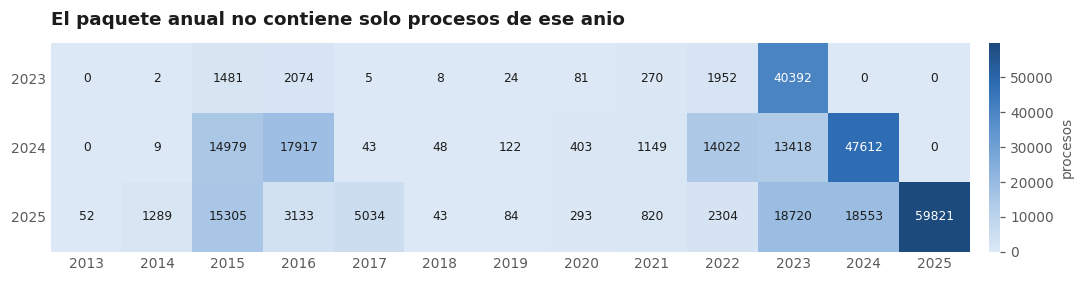

In [8]:
cruce = (cruda.groupBy("periodo_archivo")
              .pivot("anio")
              .count()
              .orderBy("periodo_archivo")
              .toPandas()
              .set_index("periodo_archivo")
              .fillna(0))

viz.mapa_calor(
    cruce,
    titulo="El paquete anual no contiene solo procesos de ese anio",
    porque="""Justifica la politica de ventana temporal. La diagonal deberia concentrar
              casi toda la masa si cada paquete trajera solo procesos de su anio. Las celdas
              fuera de la diagonal son procesos antiguos republicados, que inflarian la serie
              temporal con actividad que no ocurrio en esa fecha.""",
    nombre="f01_paquete_vs_anio_convocatoria",
    etiqueta_valor="procesos",
)
artefactos.exportar(cruce.reset_index(), "p1_paquete_vs_anio",
                    "Procesos por anio de paquete descargado frente a anio de convocatoria.")
cruce.astype(int)

In [9]:
reparables = {"\u00a5": "N con tilde", "\u00a4": "n con tilde", "\u00a2": "o con tilde",
              "\u00e0": "O con tilde", "\u00d6": "I con tilde", "\u00b5": "A con tilde",
              "\u0090": "E con tilde", "\u00a0": "a con tilde", "\u00d2": "O con tilde",
              "\u00cc": "I con tilde", "\u00c8": "E con tilde"}
ambiguos = {"\u00bf": "interrogacion invertida", "\u00b4": "acento suelto",
            "\u00a8": "dieresis suelta", "\u00bd": "un medio"}

filas = []
for c, destino in list(reparables.items()) + list(ambiguos.items()):
    n = cruda.filter(F.col("objeto").contains(c)).count()
    filas.append({"codigo": f"U+{ord(c):04X}",
                  "tratamiento": f"reparado a {destino}" if c in reparables else f"conservado, {destino}",
                  "filas_que_lo_contienen": n})

verif = pd.DataFrame(filas)
artefactos.exportar(verif, "p1_verificacion_codificacion",
                    "Caracteres corrompidos reparados y conservados, con su conteo tras la reparacion.")
verif

,codigo,tratamiento,filas_que_lo_contienen
0,U+00A5,reparado a N con tilde,0
1,U+00A4,reparado a n con tilde,0
2,U+00A2,reparado a o con tilde,0
3,U+00E0,reparado a O con tilde,0
4,U+00D6,reparado a I con tilde,0
5,U+00B5,reparado a A con tilde,0
6,U+0090,reparado a E con tilde,0
7,U+00A0,reparado a a con tilde,0
8,U+00D2,reparado a O con tilde,0
9,U+00CC,reparado a I con tilde,0


El resultado confirma que la reparación funcionó: los once caracteres reparables aparecen en cero filas, porque ya fueron sustituidos durante la ingesta. Los ambiguos siguen presentes, y su conteo es el dato honesto de cuánto texto queda imperfecto. Ese número es también una advertencia para la Parte II: sobre esas filas la similitud de texto será algo más baja de lo que debería, y si algún par similar esperado no aparece, este es el primer lugar donde mirar.

La lectura confirma el diagnóstico. El paquete 2024 aporta unos 47.600 procesos convocados en 2024 y casi 33.000 convocados en 2015 y 2016. Si se dejaran, la serie mensual mostraría una actividad de contratación en 2015 que es en realidad trabajo de saneamiento de registros hecho nueve años después. Se restringe el análisis a la ventana 2023 a 2025, cubierta por los tres paquetes, y se documenta el costo: se pierde alrededor del 30 por ciento de las filas.

### 6.4 Aplicación de las políticas de limpieza

Aquí está el núcleo del argumento metodológico. Cada política de limpieza está declarada en el perfil YAML con tres piezas: sobre qué columna actúa, qué acción ejecuta y por qué. El motor las aplica en orden y devuelve una bitácora con cuántas filas tocó cada una. Ninguna decisión de borrado o imputación queda escondida dentro del código, y la bitácora se exporta como artefacto para que el reporte web pueda mostrarla.

Las acciones disponibles y el criterio con el que se eligió cada una:

1. normalizar_texto recorta espacios, unifica a mayúsculas y colapsa espacios múltiples. Se aplica al objeto contractual y a los nombres de entidad y proveedor, porque son campos de digitación libre y porque de ellos dependen el shingling de la Parte II y el agrupamiento por entidad del EDA.

2. descartar_fila elimina filas que cumplen una condición. Se reserva para los casos en que no existe imputación defendible.

3. imputar_mediana rellena nulos con la mediana, opcionalmente calculada dentro de un grupo. Se prefiere la mediana a la media porque las variables aquí tienen colas largas.

4. imputar_constante convierte el nulo en una categoría explícita y visible, en lugar de borrarlo en silencio.

5. marcar_outliers agrega una bandera booleana. No elimina nada.

6. recortar winsoriza a un percentil, es decir, sustituye el valor extremo por el límite en vez de descartar la fila completa.

In [10]:
t0 = time.perf_counter()
limpia, bitacora = limpieza.aplicar(cruda, cfg)
limpia = limpia.cache()
n_limpia = limpia.count()
print(f"Tiempo de limpieza: {time.perf_counter() - t0:.1f} s")
print(f"Filas: {n_cruda:,}  ->  {n_limpia:,}   (se conserva el {100*n_limpia/n_cruda:.1f} %)")

artefactos.exportar(bitacora, "p1_bitacora_limpieza",
                    "Bitacora de limpieza: accion, filas afectadas y justificacion de cada politica.")
bitacora[["paso", "columna", "accion", "filas_afectadas", "pct_filas", "filas_restantes"]]

Tiempo de limpieza: 8.3 s
Filas: 281,462  ->  177,398   (se conserva el 63.0 %)


,paso,columna,accion,filas_afectadas,pct_filas,filas_restantes
0,entrada,,lectura,0,0.000,281462
1,deduplicacion,ocid,conservar_mas_reciente,0,0.000,281462
2,limpieza,objeto,normalizar_texto,63126,22.428,281462
3,limpieza,comprador_nombre,normalizar_texto,16520,5.869,281462
4,limpieza,proveedor_principal_nombre,normalizar_texto,4925,1.750,281462
5,limpieza,monto_pen,descartar_fila,22830,8.111,258632
6,limpieza,fecha,descartar_fila,0,0.000,258632
7,limpieza,fecha,descartar_fila,81234,31.409,177398
8,limpieza,n_postores,imputar_mediana,6655,3.751,177398
9,limpieza,departamento,imputar_constante,0,0.000,177398


La bitácora completa, con la justificación de cada decisión, se lee mejor una política por vez.

In [11]:
for _, r in bitacora.iterrows():
    if r["paso"] == "entrada":
        continue
    print(f"[{r['accion']}] sobre {r['columna']}")
    print(f"  detalle : {r['detalle']}")
    print(f"  efecto  : {r['filas_afectadas']:,} filas ({r['pct_filas']} %) -> quedan {r['filas_restantes']:,}")
    print(f"  razon   : {r['razon']}")
    print()

[conservar_mas_reciente] sobre ocid
  detalle : orden por fecha_publicacion descendente
  efecto  : 0 filas (0.0 %) -> quedan 281,462
  razon   : El paquete OCDS entrega releases compiladas. Un mismo ocid puede aparecer mas de una vez cuando el proceso fue republicado tras una modificacion. Conservamos la version con fecha de publicacion mas reciente porque es la que refleja el estado final del proceso, y descartamos las anteriores.

[normalizar_texto] sobre objeto
  detalle : trim, mayusculas, espacios colapsados
  efecto  : 63,126 filas (22.428 %) -> quedan 281,462
  razon   : El objeto contractual se digita libremente por cada entidad, con mezcla de mayusculas, minusculas y espacios dobles. Sin normalizar, el shingling de la Parte II produciria falsos negativos entre textos identicos que solo difieren en formato.

[normalizar_texto] sobre comprador_nombre
  detalle : trim, mayusculas, espacios colapsados
  efecto  : 16,520 filas (5.869 %) -> quedan 281,462
  razon   : El nombre de l

### 6.5 El embudo de limpieza

La figura traduce la bitácora a una imagen. **Se genera porque** el lector necesita ver de un vistazo cuánto dato costó cada decisión, y porque una tabla de siete filas no transmite la magnitud relativa de los recortes. **Responde a: control de calidad del dato.**

,etapa,filas_restantes
0,entrada,281462
1,conservar_mas_reciente en ocid,281462
2,normalizar_texto en objeto,281462
3,normalizar_texto en comprador_nombre,281462
4,normalizar_texto en proveedor_principal_nombre,281462
5,descartar_fila en monto_pen,258632
6,descartar_fila en fecha,258632
7,descartar_fila en fecha,177398
8,imputar_mediana en n_postores,177398
9,imputar_constante en departamento,177398


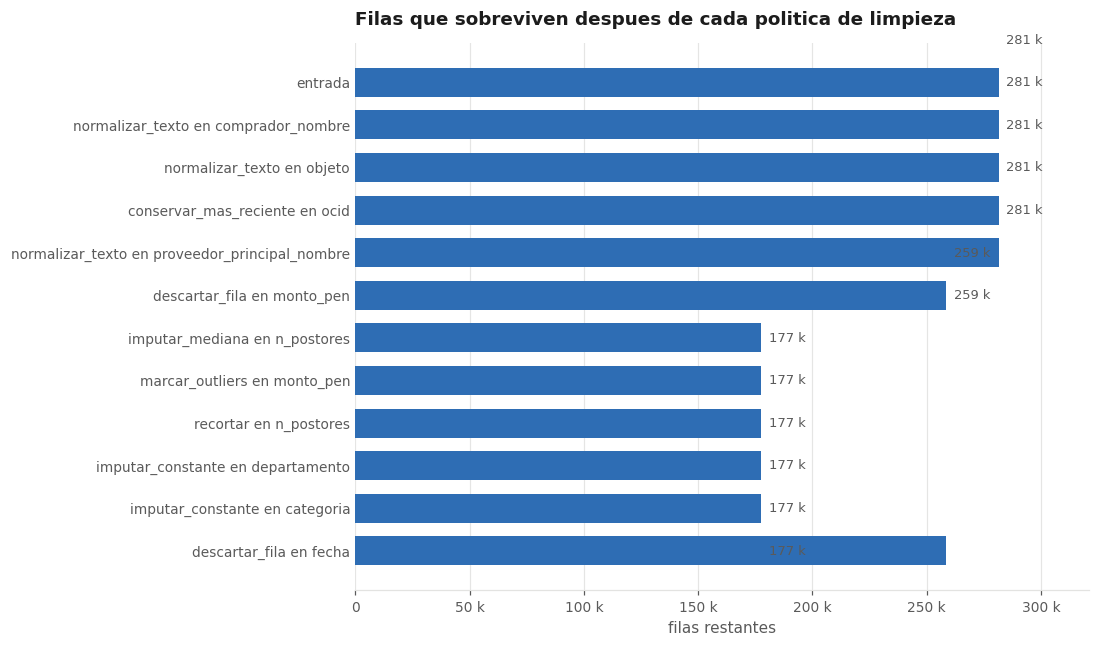

In [12]:
embudo = bitacora[["accion", "columna", "filas_restantes"]].copy()
embudo["etapa"] = embudo.apply(
    lambda r: "entrada" if r["accion"] == "lectura" else f"{r['accion']} en {r['columna']}", axis=1)

viz.barras_h(
    embudo, "etapa", "filas_restantes",
    titulo="Filas que sobreviven despues de cada politica de limpieza",
    porque="""Hace visible el costo en datos de cada decision del preprocesamiento. Las dos
              politicas que realmente recortan son el descarte de montos no positivos y la
              restriccion de la ventana temporal; el resto imputa o marca sin perder filas.""",
    nombre="f02_embudo_limpieza",
    etiqueta_x="filas restantes",
    alto_fila=0.42,
)
embudo[["etapa", "filas_restantes"]]

### 6.6 Tratamiento de valores extremos

El monto es la variable más asimétrica de la tabla: conviven compras de unos pocos miles de soles con obras de cientos de millones. Aplicar el criterio del rango intercuartílico en escala lineal marcaría como extremo a una fracción enorme de la cola, que en este dominio es dato legítimo. Por eso el criterio se aplica sobre el logaritmo del monto, que reconoce esa asimetría.

La decisión que importa no es el método sino qué se hace con lo detectado: los extremos se marcan y se conservan. En contratación pública los montos altos son exactamente los casos de mayor interés para la pregunta de concentración. Eliminarlos destruiría el fenómeno que se quiere estudiar. La columna monto_pen_outlier queda disponible para que cualquier análisis posterior los excluya si lo necesita, pero esa es una decisión del análisis, no del preprocesamiento.

Con el número de postores la situación es distinta. Se observan valores de hasta trescientos postores en procedimientos donde eso es materialmente imposible, y a diferencia del monto, ese extremo no tiene lectura sustantiva: es un error de carga en el SEACE. Se winsoriza al percentil 99,9 en lugar de descartar la fila, porque la fila sigue aportando su monto, su objeto y su canasta de ítems.

In [13]:
extremos = limpia.groupBy("monto_pen_outlier").agg(
    F.count("*").alias("procesos"),
    F.round(F.min("monto_pen"), 2).alias("monto_min"),
    F.round(F.percentile_approx("monto_pen", 0.5), 2).alias("monto_mediano"),
    F.round(F.max("monto_pen"), 2).alias("monto_max"),
    F.round(F.sum("monto_pen") / 1e6, 1).alias("monto_total_millones"),
).toPandas()

artefactos.exportar(extremos, "p1_outliers_monto",
                    "Procesos marcados como extremos por monto frente al resto.")
extremos

,monto_pen_outlier,procesos,monto_min,monto_mediano,monto_max,monto_total_millones
0,True,565,0.04,1.058028e+08,1.134909e+09,93648.6
1,False,176833,592.11,1.773900e+05,6.480841e+07,154957.5


In [14]:
resumen_num = perfilado.resumen_numerico(limpia, cfg.roles["numericas"])
artefactos.exportar(resumen_num, "p1_resumen_numerico",
                    "Estadisticos robustos de las variables numericas tras la limpieza.")
resumen_num.round(2)

,columna,n,media,desv,min,p01,p25,mediana,p75,p95,p99,max
0,monto_pen,177398,1401403.17,14159909.51,0.04,12000.0,84678.0,177728.63,445680.0,3391536.94,16385458.19,1.134909e+09
1,n_postores,177398,12.92,14.22,1.00,1.0,3.0,9.00,17.0,40.00,69.00,1.070000e+02
2,n_items,177398,0.80,1.50,0.00,0.0,0.0,1.00,1.0,1.00,3.00,3.400000e+02
3,duracion_convocatoria_dias,166236,0.00,0.00,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.000000e+00


El resumen numérico deja al descubierto una columna inservible, y conviene decirlo en lugar de dejarla pasar. La duración de la convocatoria, calculada como la diferencia entre el fin y el inicio del período de ofertas, vale cero en todas las filas: media cero, desviación cero, todos los cuantiles cero. La causa es que la fuente publica ambas fechas con el mismo valor, de modo que el campo existe pero no codifica ninguna información.

La consecuencia práctica es que esta variable queda descartada para todo el proyecto. No se imputa, porque no hay nada que imputar; no se elimina de la tabla, porque su presencia documenta el hallazgo; y no se usa en ningún análisis posterior. Es un buen recordatorio de por qué el perfilado va antes que el análisis: una variable con nombre prometedor puede estar vacía de contenido aunque no tenga un solo nulo.

## 7. Etapa de transformación

La tabla limpia se persiste en Parquet particionada por año. Tres motivos, en orden de importancia.

1. **Formato columnar.** El EDA lee entre dos y cinco columnas por consulta sobre una tabla de treinta y cuatro. Parquet permite leer solo esas, mientras que CSV obliga a deserializar la fila completa. Esta es la diferencia que más se nota en la práctica.

2. **Partición por año.** Casi todas las consultas del EDA y toda la simulación de flujo de la Parte IV filtran o agrupan por período. Con la partición física, Spark descarta directorios enteros sin abrirlos, lo que se verifica más abajo leyendo el plan de ejecución.

3. **Esquema conservado.** Parquet guarda los tipos. Las Partes II a V leen esta tabla sin repetir conversiones ni volver a inferir nada, y arrancan de un estado idéntico al que deja este notebook.

In [15]:
ruta_parquet = cfg.ruta("procesada")

t0 = time.perf_counter()
artefactos.exportar_parquet(limpia, ruta_parquet, particion=cfg["particionado"]["columna"])
print(f"Escritura en Parquet: {time.perf_counter() - t0:.1f} s")

tam_raw = sum(f.stat().st_size for f in cfg.ruta("raw").rglob("*.csv"))
tam_pq = sum(f.stat().st_size for f in ruta_parquet.rglob("*.parquet"))
print(f"CSV crudo    : {tam_raw/1e9:.2f} GB (21 tablas x 3 anios)")
print(f"Parquet final: {tam_pq/1e6:.1f} MB (1 tabla analitica particionada)")
print(f"Particiones fisicas: {sorted(p.name for p in ruta_parquet.glob('anio=*'))}")

Escritura en Parquet: 2.3 s
CSV crudo    : 2.98 GB (21 tablas x 3 anios)
Parquet final: 35.5 MB (1 tabla analitica particionada)
Particiones fisicas: ['anio=2023', 'anio=2024', 'anio=2025']


In [16]:
# A partir de aqui se trabaja sobre la tabla persistida, igual que lo haran las
# Partes II a V. Es tambien la forma de verificar que el parquet quedo usable.
datos = spark.read.parquet(str(ruta_parquet))
datos.createOrReplaceTempView("contrataciones")

print(f"Filas: {datos.count():,}   Columnas: {len(datos.columns)}")
print(f"Particiones en memoria al leer: {datos.rdd.getNumPartitions()}")
datos.select("ocid", "fecha", "anio", "categoria", "nivel_gobierno", "departamento",
             "monto_pen", "n_postores", "n_items", "tiene_adjudicacion").show(6, truncate=26)

Filas: 177,398   Columnas: 35
Particiones en memoria al leer: 8
+--------------------------+-------------------+----+---------+-----------------+------------+----------+----------+-------+------------------+
|                      ocid|              fecha|anio|categoria|   nivel_gobierno|departamento| monto_pen|n_postores|n_items|tiene_adjudicacion|
+--------------------------+-------------------+----+---------+-----------------+------------+----------+----------+-------+------------------+
|ocds-dgv273-seacev3-100...|2023-12-28 16:31:00|2023|    goods|Gobierno regional|       CUSCO| 280069.06|      11.0|      1|              true|
|ocds-dgv273-seacev3-100...|2023-10-23 23:16:00|2023|    works|   Gobierno local|         ICA|1709601.56|      23.0|      1|              true|
|ocds-dgv273-seacev3-101...|2023-12-29 22:17:00|2023|    goods|Gobierno regional|        PUNO| 2199321.6|      10.0|      2|              true|
|ocds-dgv273-seacev3-101...|2023-02-28 18:14:00|2023|    goods|Gobierno 

### Esquema final

Este es el esquema que heredan todas las partes siguientes. La columna de la derecha indica qué técnica del curso consume cada campo, que es el criterio con el que se decidió conservarlo.

| Campo | Tipo | Para qué se conserva |
| --- | --- | --- |
| ocid | string | Clave del proceso. Identifica la canasta en la Parte V y el documento en las Partes II y III. |
| fecha | timestamp | Ordena el flujo de la Parte IV. Sostiene el análisis de estacionalidad. |
| anio, mes, anio_mes | int, int, string | Agregación temporal y clave de partición física. |
| objeto | string | Texto libre del que salen los shingles de la Parte II y los vectores TF-IDF de la Parte III. |
| items_cubso, familias_cubso | array de string | Representación del proceso como conjunto. Entrada directa de Jaccard, MinHash y FP-Growth. |
| comprador_id, comprador_nombre | string | Entidad contratante. Agrupación del EDA y entidad comparable en la Parte II. |
| proveedor_principal_id, proveedor_principal_nombre | string | Proveedor adjudicado. Sostiene la pregunta de concentración. |
| nivel_gobierno, departamento | string | Variables derivadas para el corte territorial e institucional. |
| categoria, metodo, metodo_detalle | string | Variables categóricas del EDA y candidatas a ítem de la canasta ampliada. |
| monto_pen | double | Variable de magnitud. Es la que responde a la pregunta 1. |
| n_postores | double | Medida de competencia. Es la que responde a la pregunta 2. |
| duracion_convocatoria_dias | double | Descartada. La fuente publica inicio y fin del período de ofertas con el mismo valor, de modo que la columna vale cero en todas las filas. Se conserva solo como registro del hallazgo. |
| n_items, n_proveedores | bigint | Tamaño de la canasta y grado de fraccionamiento. |
| tiene_adjudicacion | boolean | Filtro obligatorio para todo análisis centrado en proveedores. |
| n_postores_imputado, monto_pen_outlier | boolean | Trazabilidad del preprocesamiento. Permiten rehacer cualquier análisis sin los valores intervenidos. |

## 8. Análisis exploratorio con Spark DataFrames y Spark SQL

El enunciado pide cubrir como mínimo tres frentes: distribución temporal, distribución de las variables categóricas y de los montos, y frecuencia de las entidades principales. Cada uno se aborda abajo con su figura y su interpretación. Antes de cada figura se indica por qué se genera y a cuál de las tres preguntas responde, porque una figura que no responde a nada es una salida acumulada, no un hallazgo.

Todo el cálculo ocurre en Spark. A pandas solo llega el agregado ya reducido, que en el peor caso son unas pocas decenas de filas.

### 8.1 Distribución temporal

**Por qué esta figura.** La serie mensual es el primer control de que la ventana temporal quedó limpia, y a la vez es la evidencia directa de la pregunta 3. Se grafican dos series en figuras separadas, no superpuestas en dos ejes: el número de procesos y el monto convocado miden cosas distintas y en escalas distintas, y un gráfico de doble eje invitaría a leer una correlación visual que no está garantizada.

**Responde a: pregunta 3, estacionalidad del gasto.**

,anio_mes,procesos,monto_millones,monto_mediano
30,2025-07-01,5689,9605.9,185984.0
31,2025-08-01,6255,6272.7,179209.8
32,2025-09-01,6066,9005.2,180000.0
33,2025-10-01,5748,7233.0,173635.0
34,2025-11-01,3380,3709.1,137788.0
35,2025-12-01,942,2250.1,97650.0


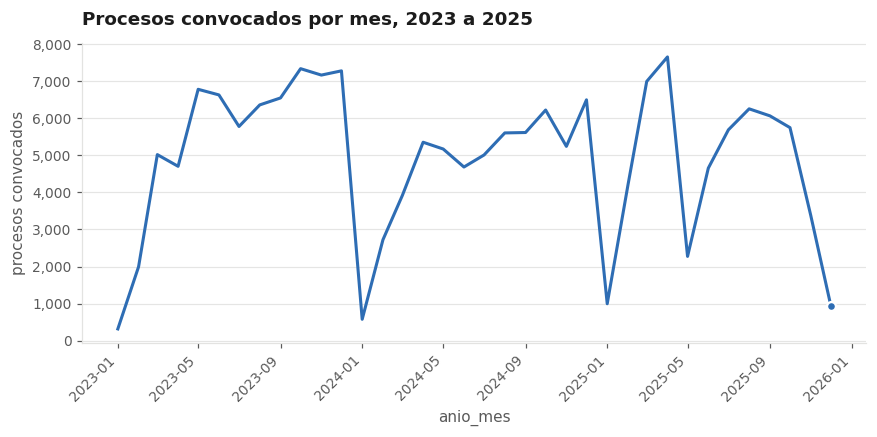

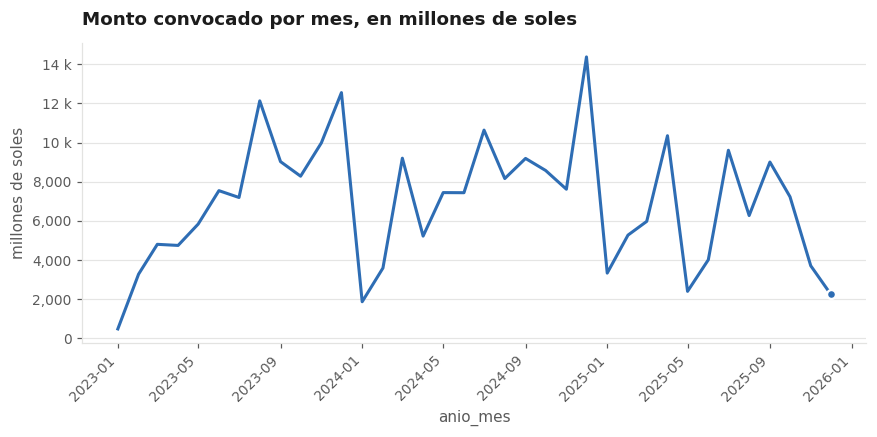

In [17]:
mensual = spark.sql("""
    SELECT anio_mes,
           COUNT(*)                     AS procesos,
           SUM(monto_pen) / 1e6         AS monto_millones,
           PERCENTILE_APPROX(monto_pen, 0.5) AS monto_mediano
    FROM contrataciones
    GROUP BY anio_mes
    ORDER BY anio_mes
""").toPandas()
mensual["anio_mes"] = pd.to_datetime(mensual["anio_mes"])

viz.serie_tiempo(mensual, "anio_mes", ["procesos"],
    titulo="Procesos convocados por mes, 2023 a 2025",
    porque="""Primer control de la ventana temporal y base de la pregunta sobre estacionalidad.
              Un mes con caida abrupta indicaria un problema de cobertura del paquete, no una
              caida real de la contratacion.""",
    nombre="f03_procesos_por_mes", etiqueta_y="procesos convocados")

viz.serie_tiempo(mensual, "anio_mes", ["monto_millones"],
    titulo="Monto convocado por mes, en millones de soles",
    porque="""Se separa del conteo de procesos porque son magnitudes de escalas distintas.
              Superponerlas en dos ejes verticales sugeriria una relacion que la figura no
              puede sostener.""",
    nombre="f04_monto_por_mes", etiqueta_y="millones de soles")

artefactos.exportar(mensual, "p1_serie_mensual",
                    "Procesos, monto total y monto mediano por mes.")
mensual.tail(6).round(1)

**Por qué esta figura.** El promedio mensual sobre tres años aísla el patrón de calendario del ruido de cada año particular. Es la forma directa de contestar si existe apresuramiento de cierre de ejercicio, porque compara diciembre contra el resto de meses con los tres años superpuestos.

**Responde a: pregunta 3.**

anio,2023,2024,2025
ene,316,576,995
feb,1995,2722,4202
mar,5020,3918,6995
abr,4704,5354,7656
may,6782,5171,2273
jun,6631,4685,4655
jul,5779,5010,5689
ago,6361,5605,6255
sep,6549,5616,6066
oct,7339,6223,5748


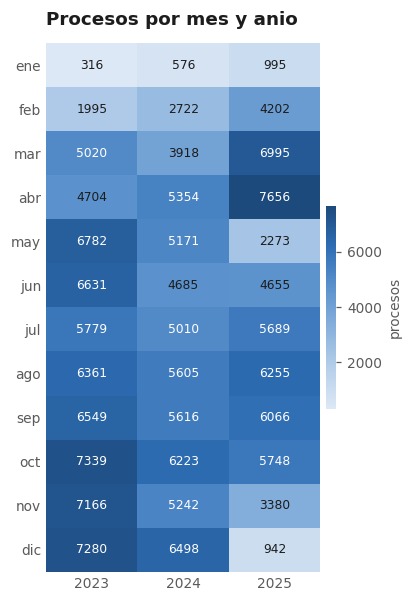

In [18]:
estacional = spark.sql("""
    SELECT mes, anio, COUNT(*) AS procesos
    FROM contrataciones
    GROUP BY mes, anio
""").toPandas().pivot(index="mes", columns="anio", values="procesos").fillna(0)
estacional.index = ["ene", "feb", "mar", "abr", "may", "jun",
                    "jul", "ago", "sep", "oct", "nov", "dic"][:len(estacional)]

viz.mapa_calor(estacional,
    titulo="Procesos por mes y anio",
    porque="""Aisla el patron de calendario del ruido de cada anio. Si hubiera apresuramiento
              de cierre presupuestal, diciembre deberia oscurecerse en las tres columnas a la
              vez, no en una sola.""",
    nombre="f05_estacionalidad_mes_anio", etiqueta_valor="procesos")

artefactos.exportar(estacional.reset_index().rename(columns={"index": "mes"}),
                    "p1_estacionalidad", "Procesos por mes y anio para el analisis de estacionalidad.")
estacional.astype(int)

**Interpretación.** Diciembre es el mes con más convocatorias tanto en 2023, con 7.280 procesos, como en 2024, con 6.498, y en ambos casos es el máximo de su año. El contraste es más nítido en dinero: diciembre de 2024 concentra 14.373 millones de soles, el máximo de toda la serie y más del doble que noviembre del mismo año. Que el pico se repita en los dos años completos es lo que permite leerlo como efecto del calendario presupuestal y no como ruido de un año particular.

Hay que anotar una limitación de cobertura antes de sacar cualquier otra conclusión temporal. El tramo final de 2025 cae a 3.380 convocatorias en noviembre y 942 en diciembre, frente a un nivel habitual cercano a 6.000. Esa caída no es una caída real de la contratación: los procesos tardan en entrar al registro OCDS, de modo que los meses más recientes están subpublicados en el paquete descargado. La ventana comparable para conclusiones estacionales son entonces 2023 y 2024, y la Parte IV tendrá que respetar esa misma advertencia al simular el flujo.

### 8.2 Distribución del monto

**Por qué esta figura.** Toda decisión posterior sobre el monto depende de su forma. En escala lineal el 99 por ciento de la masa se apila contra el eje y la figura no informa nada; en escala logarítmica se ve el rango completo y se aprecia si la distribución es unimodal o si los procedimientos de distinto tipo forman modos separados. También es lo que justifica haber usado el criterio de extremos sobre el logaritmo y no sobre el valor directo.

**Responde a: control previo a las preguntas 1 y 2.**

Monto total en la ventana: S/ 248.6 mil millones
Mediana: S/ 178,155   Media: S/ 1,401,403
La media es 7.9 veces la mediana, lo que confirma la asimetria.


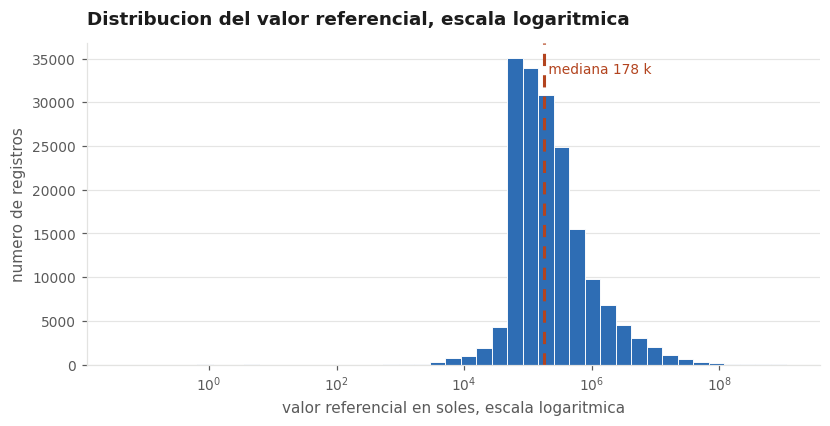

In [19]:
montos = np.array(datos.select("monto_pen").toPandas()["monto_pen"])

viz.histograma_log(montos,
    titulo="Distribucion del valor referencial, escala logaritmica",
    porque="""El monto abarca seis ordenes de magnitud. En escala lineal la figura seria una
              sola barra pegada al eje. El logaritmo es lo que hace legible el rango completo y
              lo que justifica haber aplicado el criterio de extremos sobre esa misma escala.""",
    nombre="f06_distribucion_monto", etiqueta_x="valor referencial en soles, escala logaritmica")

print(f"Monto total en la ventana: S/ {montos.sum()/1e9:,.1f} mil millones")
print(f"Mediana: S/ {np.median(montos):,.0f}   Media: S/ {montos.mean():,.0f}")
print(f"La media es {montos.mean()/np.median(montos):.1f} veces la mediana, lo que confirma la asimetria.")

**Interpretación.** La distribución tiene la forma típica de una cola larga, y los números lo confirman: la mediana del valor referencial es de 177.729 soles mientras que la media es de 1.401.403, casi ocho veces mayor. En una distribución simétrica ambas coincidirían; aquí la media está arrastrada por un puñado de contratos enormes y por eso no describe a ningún proceso representativo.

Ese puñado se puede cuantificar, y es el argumento empírico de por qué los extremos se marcaron en vez de eliminarse. Los 565 procesos señalados como extremos, que son el 0,3 por ciento de las filas, concentran 93.649 de los 248.606 millones de soles de la ventana, es decir el 38 por ciento del gasto. Eliminarlos habría dejado un conjunto de datos más ordenado y habría borrado más de un tercio del dinero público que se quiere estudiar.

### 8.3 Variables categóricas

**Por qué estas figuras.** Las tres variables categóricas principales, categoría de contratación, método de selección y nivel de gobierno, definen los cortes con los que se leen todos los demás hallazgos. Se grafican como barras horizontales ordenadas porque el trabajo del dato es comparar magnitudes entre categorías con etiquetas largas, y el valor va rotulado sobre cada barra para que la lectura no dependa del color.

**Responde a: contexto necesario para las preguntas 1 y 2.**

,metodo_detalle,procesos,monto_miles_millones,postores_medio
0,Adjudicación Simplificada,82503,47.14,16.14
1,Subasta Inversa Electrónica,21150,10.00,8.23
2,Comparación de Precios,12555,0.85,3.14
3,Contratación Directa,11049,14.53,1.23
4,Licitación Pública Abreviada,9601,6.32,13.61
5,Licitación Pública,9242,106.64,21.02
6,Concurso Público Abreviado,8926,1.92,14.55
7,Concurso Público,6627,27.14,26.07
8,Regímen Especial,4367,4.81,1.64
9,Convenio,4009,10.29,1.98


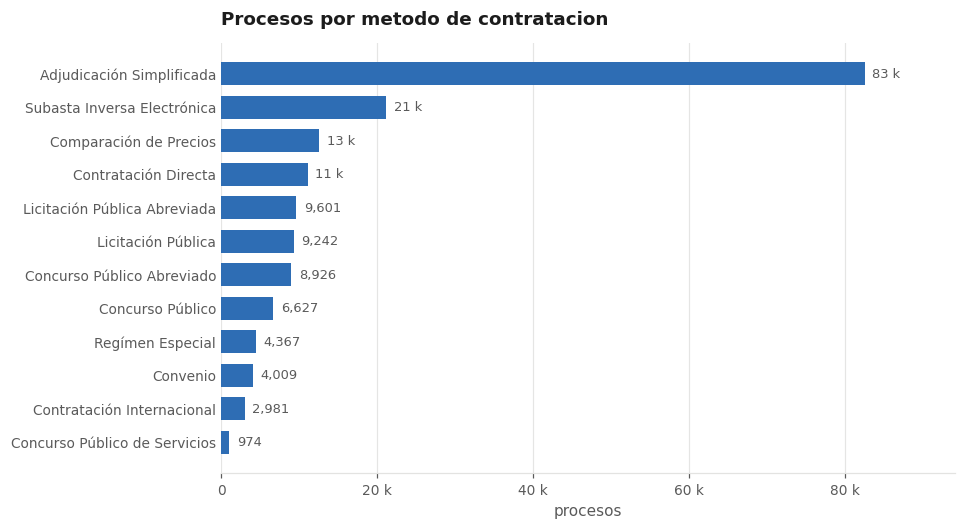

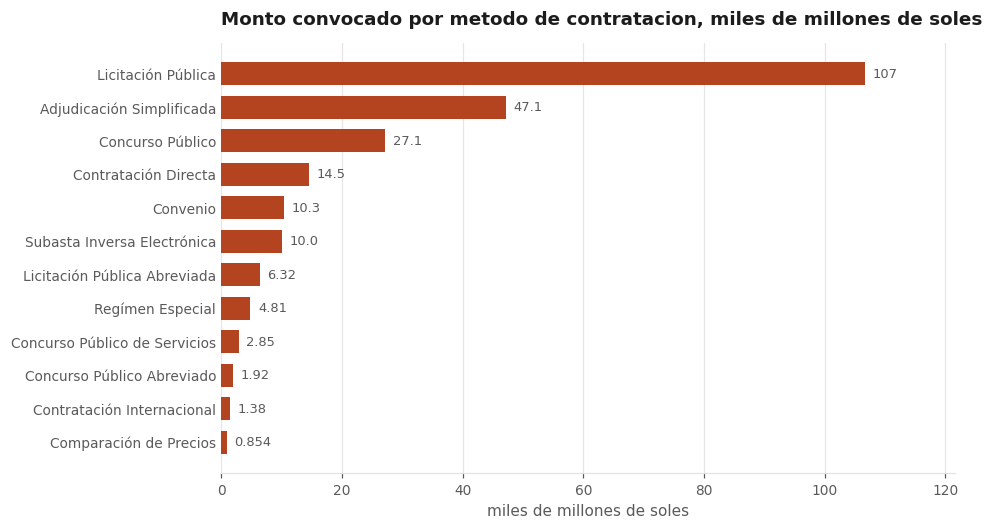

In [20]:
por_categoria = spark.sql("""
    SELECT categoria,
           COUNT(*)             AS procesos,
           SUM(monto_pen)/1e9   AS monto_miles_millones
    FROM contrataciones GROUP BY categoria ORDER BY procesos DESC
""").toPandas()

por_metodo = spark.sql("""
    SELECT metodo_detalle,
           COUNT(*)             AS procesos,
           SUM(monto_pen)/1e9   AS monto_miles_millones,
           AVG(n_postores)      AS postores_medio
    FROM contrataciones GROUP BY metodo_detalle ORDER BY procesos DESC LIMIT 12
""").toPandas()

viz.barras_h(por_metodo, "metodo_detalle", "procesos",
    titulo="Procesos por metodo de contratacion",
    porque="""El metodo determina las reglas de competencia de cada proceso y es el corte con
              el que se interpreta cualquier medida de numero de postores. Tambien fija el grupo
              dentro del cual se imputo la mediana de postores.""",
    nombre="f07_procesos_por_metodo", etiqueta_x="procesos")

viz.barras_h(por_metodo, "metodo_detalle", "monto_miles_millones",
    titulo="Monto convocado por metodo de contratacion, miles de millones de soles",
    porque="""Se contrasta con la figura anterior a proposito: el metodo que mas procesos
              concentra no es el que mas dinero mueve, y esa diferencia es un hallazgo en si
              mismo.""",
    nombre="f08_monto_por_metodo", etiqueta_x="miles de millones de soles",
    color=viz.PALETA[1])

artefactos.exportar(por_metodo, "p1_por_metodo", "Procesos, monto y postores medios por metodo de contratacion.")
artefactos.exportar(por_categoria, "p1_por_categoria", "Procesos y monto por categoria de contratacion.")
por_metodo.round(2)

Procesos sin nivel de gobierno reconocido: 3.2 %


,nivel_gobierno,procesos,monto_miles_millones,entidades
0,Gobierno nacional,28590,86.85,260
1,Gobierno regional,39736,63.72,528
2,Gobierno local,73456,62.02,1855
3,Empresa del Estado,13529,16.98,116
4,Universidad publica,7094,5.82,53
5,Fuerzas armadas y policiales,5918,5.55,21
6,Otro,5613,5.43,98
7,Establecimiento de salud,3254,2.14,28
8,Unidad educativa,208,0.10,9


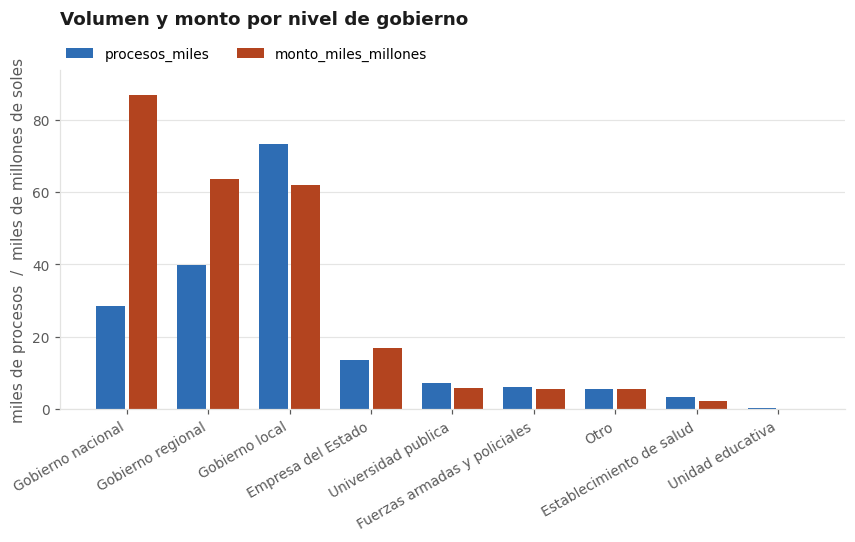

In [21]:
por_nivel = spark.sql("""
    SELECT nivel_gobierno,
           COUNT(*)                  AS procesos,
           SUM(monto_pen)/1e9        AS monto_miles_millones,
           COUNT(DISTINCT comprador_id) AS entidades
    FROM contrataciones GROUP BY nivel_gobierno ORDER BY monto_miles_millones DESC
""").toPandas()

viz.barras_agrupadas(
    por_nivel.assign(procesos_miles=por_nivel["procesos"]/1000),
    "nivel_gobierno", ["procesos_miles", "monto_miles_millones"],
    titulo="Volumen y monto por nivel de gobierno",
    porque="""El nivel de gobierno es una variable derivada, no venia en el dato crudo. Esta
              figura verifica que la derivacion por expresion regular sobre el nombre de la
              entidad produjo grupos con tamanos razonables, y a la vez muestra el contraste
              entre quien convoca mas procesos y quien mueve mas dinero.""",
    nombre="f09_nivel_gobierno", etiqueta_y="miles de procesos  /  miles de millones de soles")

artefactos.exportar(por_nivel, "p1_por_nivel_gobierno", "Procesos, monto y entidades por nivel de gobierno.")
residual = por_nivel.loc[por_nivel["nivel_gobierno"] == "Otro", "procesos"]
pct_residual = 100 * (residual.iloc[0] if len(residual) else 0) / por_nivel["procesos"].sum()
print(f"Procesos sin nivel de gobierno reconocido: {pct_residual:.1f} %")
por_nivel.round(2)

Conviene ser explícito sobre la naturaleza de esta variable, porque es la única del esquema que no venía en el dato crudo. El estándar OCDS no publica el nivel de gobierno de la entidad compradora, así que se deriva por expresión regular sobre su nombre: quien se llama municipalidad es gobierno local, quien se llama gobierno regional es regional, y así sucesivamente. Es una heurística, no una clasificación oficial, y tiene dos límites que hay que declarar.

El primero es el residual. La categoría Otro recoge lo que ninguna regla reconoce, y su tamaño es la medida honesta de cuánto falla la derivación. El porcentaje se imprime arriba, junto a la tabla.

El segundo es que algunos nombres son ambiguos por naturaleza. Un fondo de inversiones municipal lleva la palabra fondo y ninguna referencia a su municipalidad, de modo que la regla lo asigna a gobierno nacional. Son casos minoritarios, pero existen, y ningún análisis que dependa críticamente de esta variable debería presentarse sin esa advertencia. Para las tres preguntas de interés la variable cumple su función, que es ofrecer un corte institucional grueso, no una clasificación presupuestal exacta.

**Interpretación.** Las dos figuras anteriores muestran un desacople que conviene subrayar, porque es el primer hallazgo no obvio del EDA. La Adjudicación Simplificada es con diferencia el método más usado, con 82.503 procesos, casi la mitad del total, pero mueve 47,1 mil millones de soles. La Licitación Pública, con apenas 9.242 procesos, el 5 por ciento, mueve 106,6 mil millones, es decir el 43 por ciento de todo el dinero. Contar procesos y contar soles dan rankings casi inversos, y cualquier conclusión que mezcle ambas lecturas será falsa.

El mismo desacople aparece por categoría: las obras son solo 19.976 procesos, el 11 por ciento, y concentran 140,1 mil millones, el 56 por ciento del monto. Y por nivel de gobierno, los gobiernos locales convocan 73.456 procesos, muchos más que cualquier otro grupo, pero el gobierno nacional los supera en monto con muchos menos procesos y una décima parte de las entidades.

Un dato adicional que anticipa la pregunta 2: la Contratación Directa registra un promedio de 1,23 postores. Es coherente con su naturaleza, porque el procedimiento no supone concurrencia, pero deja la advertencia de que cualquier medida agregada de competencia tiene que controlar por método antes de significar algo.

### 8.4 Frecuencia de las entidades principales

**Por qué estas figuras.** El enunciado pide explícitamente la frecuencia de las entidades o categorías principales. Aquí se mira por los dos lados del mercado, quién compra y quién vende, porque la pregunta 1 es sobre concentración y una sola de las dos vistas no la contesta. El ranking se ordena por monto y no por número de procesos, porque la pregunta es sobre a dónde va el dinero.

**Responde a: pregunta 1, concentración.**

,comprador_nombre,procesos,monto_millones
0,MTC-PROYECTO ESPECIAL DE INFRAESTRUCTURA DE TRANSPORTE NACIONAL (P...,828,18742.4
1,PROGRAMA AGUA SEGURA PARA LIMA Y CALLAO,70,8612.1
2,GOBIERNO REGIONAL DE JUNIN SEDE CENTRAL,1059,7438.8
3,SEGURO SOCIAL DE SALUD,3682,7208.8
4,GOBIERNO REGIONAL DE PASCO SEDE CENTRAL,516,7180.5
5,UNIDAD EJECUTORA 125 PROGRAMA NACIONAL DE INVERSIONES EN SALUD,129,6667.1
6,GOBIERNO REGIONAL DE LORETO - ORGANISMO PUBLICO INFRAESTRUCTURA PA...,68,6434.8
7,PROGRAMA NACIONAL DE SANEAMIENTO URBANO,406,5416.7
8,CENTRO NACIONAL DE ABASTECIMIENTO DE RECURSOS ESTRATEGICOS EN SALUD,659,4293.8
9,MTC-PROYECTO ESPECIAL DE INFRAESTRUCTURA DE TRANSPORTE DESCENTRALI...,455,4232.4


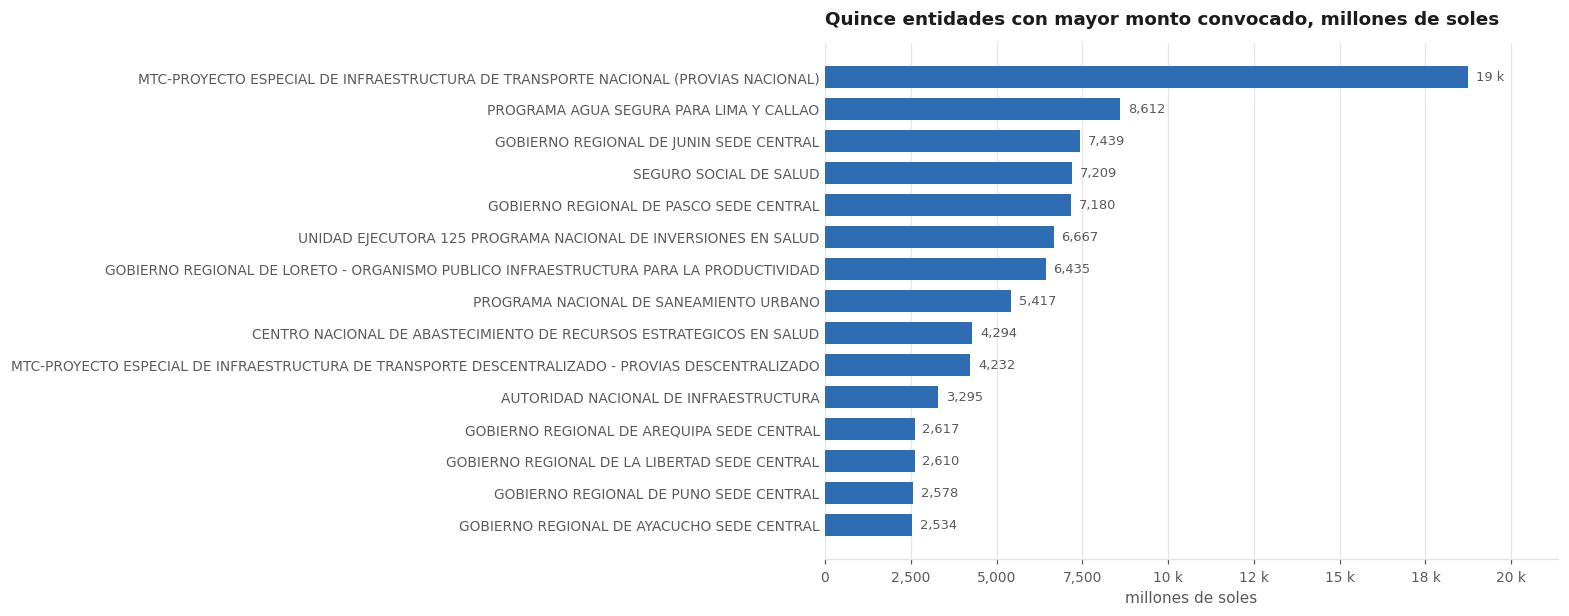

In [22]:
top_compradores = spark.sql("""
    SELECT comprador_nombre,
           COUNT(*)            AS procesos,
           SUM(monto_pen)/1e6  AS monto_millones
    FROM contrataciones
    GROUP BY comprador_nombre
    ORDER BY monto_millones DESC LIMIT 15
""").toPandas()

viz.barras_h(top_compradores, "comprador_nombre", "monto_millones",
    titulo="Quince entidades con mayor monto convocado, millones de soles",
    porque="""Responde la mitad compradora de la pregunta de concentracion. Se ordena por monto
              y no por numero de procesos porque la pregunta es a donde va el dinero, no quien
              hace mas tramites.""",
    nombre="f10_top_compradores", etiqueta_x="millones de soles")

artefactos.exportar(top_compradores, "p1_top_compradores", "Quince entidades compradoras con mayor monto.")
top_compradores.round(1)

,proveedor_principal_nombre,adjudicaciones,monto_millones
0,CONSORCIO SAN JUAN,122,1189.8
1,J Y S SERVICIOS GENERALES SOCIEDAD ANONIMA CERRADA ¿ J Y S SERVICI...,1,1134.9
2,LABORATORIOS AMERICANOS S.A.,31,1067.4
3,RIMAC SEGUROS Y REASEGUROS,96,791.1
4,PETROLEOS DEL PERU S.A.,8,754.9
5,GEOSATELITAL PERU E.I.R.L. - GEOSATELITAL E.I.R.L.,23,751.7
6,CONSORCIO CASTILLA,8,692.8
7,CONSORCIO AGUA CASTILLA,1,659.1
8,IPESA S.A.C.,161,647.2
9,CONSORCIO PUENTE CHALACO,1,615.8


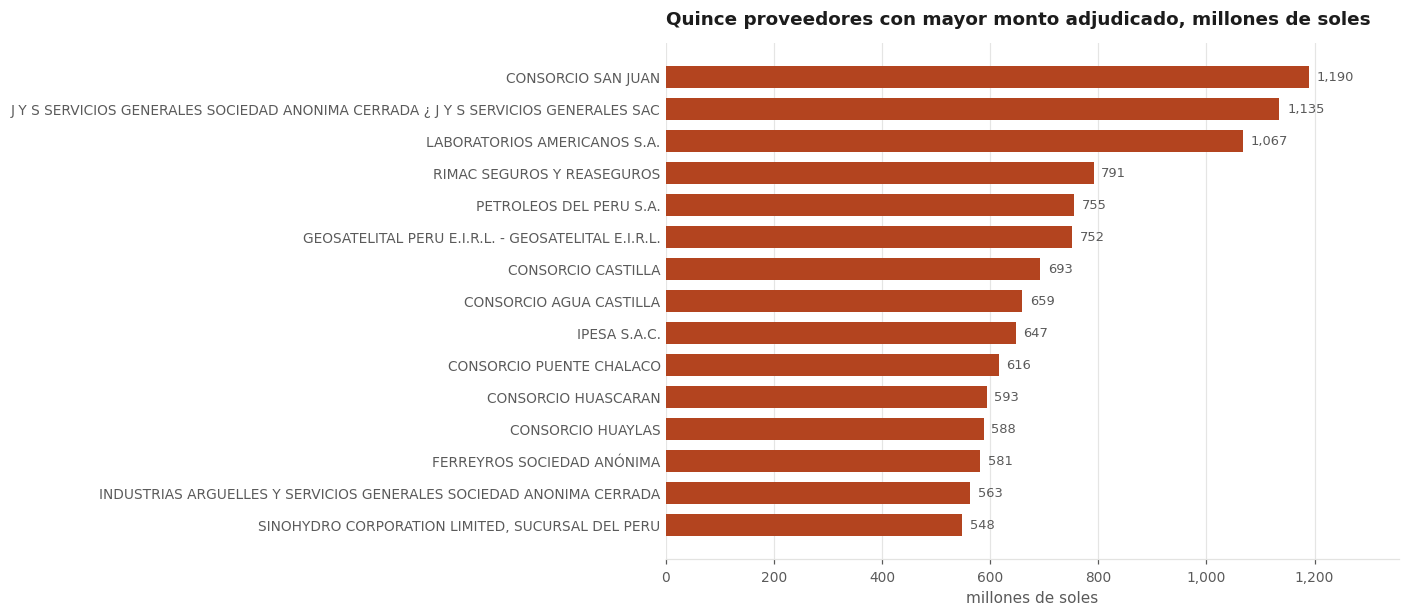

In [23]:
top_proveedores = spark.sql("""
    SELECT proveedor_principal_nombre,
           COUNT(*)            AS adjudicaciones,
           SUM(monto_pen)/1e6  AS monto_millones
    FROM contrataciones
    WHERE tiene_adjudicacion
    GROUP BY proveedor_principal_nombre
    ORDER BY monto_millones DESC LIMIT 15
""").toPandas()

viz.barras_h(top_proveedores, "proveedor_principal_nombre", "monto_millones",
    titulo="Quince proveedores con mayor monto adjudicado, millones de soles",
    porque="""La mitad vendedora de la pregunta de concentracion. Se filtra por
              tiene_adjudicacion porque incluir procesos desiertos contaria como proveedor a
              un valor nulo.""",
    nombre="f11_top_proveedores", etiqueta_x="millones de soles", color=viz.PALETA[1])

artefactos.exportar(top_proveedores, "p1_top_proveedores", "Quince proveedores con mayor monto adjudicado.")
top_proveedores.round(1)

**Por qué esta figura.** Un ranking de quince nombres dice quiénes están arriba, pero no dice cuánto pesan sobre el total. La curva de Lorenz sí, y resume la concentración en un solo número comparable entre grupos. Es la figura que contesta la pregunta 1 de forma cuantitativa, y la única del notebook que produce una métrica reutilizable en la Parte VI.

**Responde a: pregunta 1.**

Proveedores distintos con al menos una adjudicacion: 67,510


,grupo,pct_del_monto
0,top 1 % de proveedores,47.100
1,top 5 % de proveedores,70.100
2,top 10 % de proveedores,80.200
3,top 25 % de proveedores,91.300
4,coeficiente de Gini,0.857


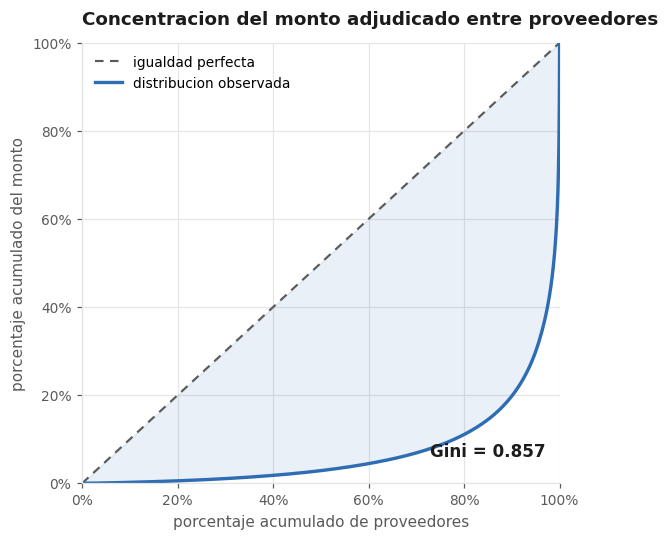

In [24]:
montos_por_proveedor = (datos.filter("tiene_adjudicacion")
                             .groupBy("proveedor_principal_id")
                             .agg(F.sum("monto_pen").alias("monto"))
                             .toPandas())

fig, gini_prov = viz.lorenz(
    montos_por_proveedor["monto"].values,
    titulo="Concentracion del monto adjudicado entre proveedores",
    porque="""Convierte la pregunta de concentracion en una medida. El ranking dice quien esta
              arriba; la curva dice cuanto del total se lleva esa minoria, que es lo que
              realmente se pregunta.""",
    nombre="f12_lorenz_proveedores", etiqueta_entidad="proveedores")

serie = np.sort(montos_por_proveedor["monto"].values)[::-1]
total = serie.sum()
hitos = pd.DataFrame([
    {"grupo": f"top {p} % de proveedores",
     "pct_del_monto": round(100 * serie[:max(1, int(len(serie) * p / 100))].sum() / total, 1)}
    for p in (1, 5, 10, 25)
])
hitos.loc[len(hitos)] = {"grupo": "coeficiente de Gini", "pct_del_monto": round(gini_prov, 3)}

artefactos.exportar(hitos, "p1_concentracion_proveedores",
                    "Participacion acumulada del monto por tramos de proveedores y coeficiente de Gini.")
print(f"Proveedores distintos con al menos una adjudicacion: {len(serie):,}")
hitos

**Por qué esta figura.** La pregunta 1 pregunta además si la concentración difiere entre territorios. El Gini calculado por separado dentro de cada departamento responde exactamente eso, y hace comparables mercados de tamaños muy distintos, cosa que el monto absoluto no permite.

**Responde a: pregunta 1, corte territorial.**

,departamento,proveedores,monto_millones,gini
18,PASCO,1282,3545.604,0.909
14,LIMA,20504,72147.903,0.899
8,HUANCAVELICA,1958,2469.456,0.833
15,LORETO,2011,4536.326,0.825
11,JUNIN,3428,5038.684,0.820
21,SAN MARTIN,1810,2946.551,0.806
12,LA LIBERTAD,3295,5268.108,0.797
3,AREQUIPA,3153,4536.433,0.792
13,LAMBAYEQUE,1739,2937.565,0.791
19,PIURA,3282,5449.311,0.789


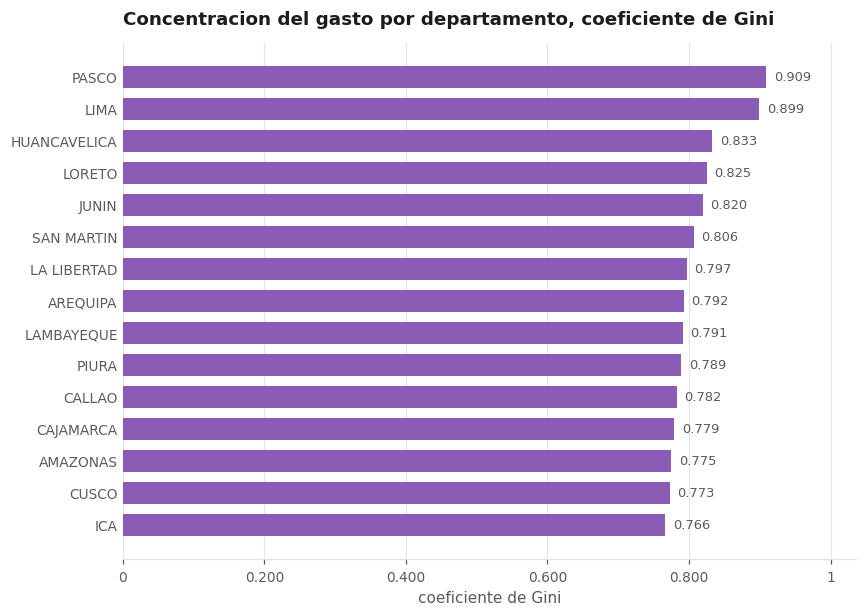

In [25]:
def gini(v):
    v = np.sort(np.asarray(v, dtype=float))
    v = v[v > 0]
    if len(v) < 20:
        return np.nan
    acum = np.cumsum(v) / v.sum()
    x = np.arange(1, len(v) + 1) / len(v)
    return float(1 - 2 * np.trapezoid(acum, x))

por_depto_prov = (datos.filter("tiene_adjudicacion")
                       .groupBy("departamento", "proveedor_principal_id")
                       .agg(F.sum("monto_pen").alias("monto"))
                       .toPandas())

territorial = (por_depto_prov.groupby("departamento")
               .agg(proveedores=("proveedor_principal_id", "nunique"),
                    monto_millones=("monto", lambda s: s.sum() / 1e6),
                    gini=("monto", gini))
               .dropna().reset_index())
territorial = territorial[territorial["proveedores"] >= 50].sort_values("gini", ascending=False)

viz.barras_h(territorial.head(15), "departamento", "gini",
    titulo="Concentracion del gasto por departamento, coeficiente de Gini",
    porque="""Hace comparables mercados de tamanos muy distintos. El monto absoluto solo diria
              que Lima gasta mas; el Gini dice en que departamentos el gasto se reparte entre
              menos manos, que es la pregunta que interesa.""",
    nombre="f13_gini_por_departamento", etiqueta_x="coeficiente de Gini", color=viz.PALETA[3])

artefactos.exportar(territorial, "p1_concentracion_departamento",
                    "Proveedores, monto y Gini por departamento, para departamentos con al menos 50 proveedores.")
territorial.round(3).head(12)

**Interpretación.** El coeficiente de Gini del monto adjudicado por proveedor es 0,857, y el desglose por tramos lo traduce a una frase directa: el uno por ciento de los proveedores se lleva el 47 por ciento del dinero, y el diez por ciento se lleva el 80 por ciento.

El corte territorial obliga a un matiz que va en dirección contraria a la esperada. Solo dos departamentos superan la concentración nacional, Pasco con 0,909 y Lima con 0,899; todos los demás quedan por debajo, hasta valores cercanos a 0,79. Esto significa que el Gini nacional no describe un patrón que se repita en cada región, sino que está empujado hacia arriba por Lima, que sola concentra 72.148 millones de soles con 20.504 proveedores. Un mercado regional típico está menos concentrado que el país, y leer el agregado nacional como si describiera a cada departamento sería un error.

Vale la pena mirar además cómo se llega a lo más alto del ranking de proveedores, porque hay dos caminos distintos. El primero acumula alrededor de 1.190 millones repartidos en 122 adjudicaciones; el segundo alcanza 1.135 millones en una sola. Son fenómenos que no se parecen en nada, y el ranking por monto los coloca uno al lado del otro sin distinguirlos. La Parte II tendrá que separar la recurrencia de la magnitud puntual.

### 8.5 Competencia efectiva

**Por qué esta figura.** La pregunta 2 relaciona competencia con monto. La forma correcta de mirarla no es un diagrama de dispersión con 177.000 puntos, que sería una mancha, sino agrupar los procesos por tramo de monto y ver cómo se mueve el número mediano de postores a lo largo de los tramos. Se usa la mediana y no el promedio porque el número de postores tiene cola larga.

**Responde a: pregunta 2, competencia efectiva.**

,tramo_monto,procesos,postores_mediano,postores_medio,pct_postor_unico
0,1. menos de 50 mil,10156,1.0,3.86,57.01100
1,2. 50 mil a 200 mil,83628,7.0,10.93,10.05900
2,3. 200 mil a 1 millon,55872,11.0,14.57,8.70700
3,4. 1 a 5 millones,15931,15.0,20.07,10.01800
4,5. 5 a 20 millones,3998,18.0,23.55,9.65500
5,6. mas de 20 millones,1158,19.0,26.73,11.39900


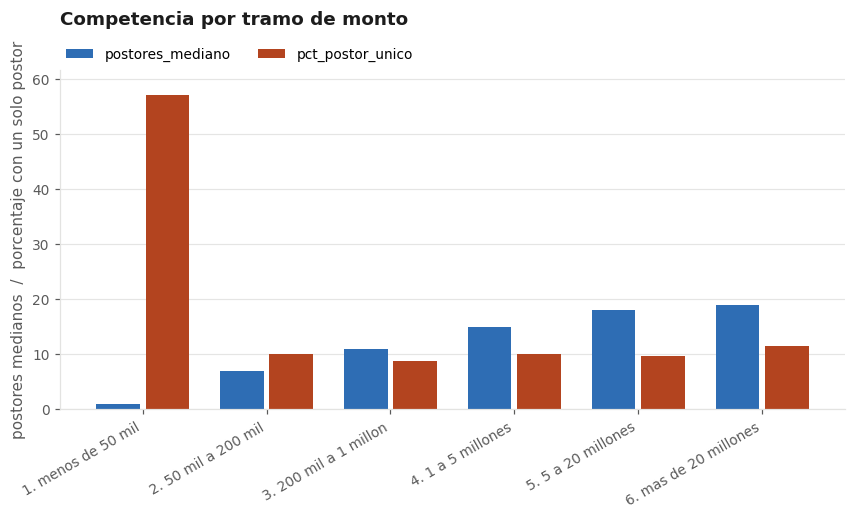

In [26]:
competencia = spark.sql("""
    SELECT CASE
             WHEN monto_pen <     50000 THEN '1. menos de 50 mil'
             WHEN monto_pen <    200000 THEN '2. 50 mil a 200 mil'
             WHEN monto_pen <   1000000 THEN '3. 200 mil a 1 millon'
             WHEN monto_pen <   5000000 THEN '4. 1 a 5 millones'
             WHEN monto_pen <  20000000 THEN '5. 5 a 20 millones'
             ELSE                            '6. mas de 20 millones'
           END                                        AS tramo_monto,
           COUNT(*)                                   AS procesos,
           PERCENTILE_APPROX(n_postores, 0.5)         AS postores_mediano,
           AVG(n_postores)                            AS postores_medio,
           AVG(CASE WHEN n_postores <= 1 THEN 1.0 ELSE 0.0 END) * 100 AS pct_postor_unico
    FROM contrataciones
    WHERE NOT n_postores_imputado
    GROUP BY 1 ORDER BY 1
""").toPandas()

viz.barras_agrupadas(competencia, "tramo_monto", ["postores_mediano", "pct_postor_unico"],
    titulo="Competencia por tramo de monto",
    porque="""Un diagrama de dispersion con 177 mil puntos seria una mancha. Agrupar por tramo
              y mirar la mediana muestra la tendencia sin perder la escala. Se excluyen los
              procesos cuyo numero de postores fue imputado, para que la relacion no la produzca
              la propia imputacion.""",
    nombre="f14_competencia_por_tramo", etiqueta_y="postores medianos  /  porcentaje con un solo postor")

artefactos.exportar(competencia, "p1_competencia_por_tramo",
                    "Postores medianos y porcentaje de procesos con un solo postor, por tramo de monto.")
competencia.round(2)

**Interpretación.** El número mediano de postores crece con el monto de forma monótona y sin excepciones: 1 postor por debajo de cincuenta mil soles, 7 entre cincuenta y doscientos mil, y de ahí en adelante 11, 15, 18 y 19. Hasta aquí, lo esperable.

Lo que interesa es dónde se rompe el patrón. En el tramo más bajo el 57 por ciento de los procesos tuvo un único postor, mientras que en todos los demás tramos esa proporción se estabiliza alrededor del 10 por ciento y ya no baja, ni siquiera por encima de veinte millones de soles. Son entonces dos fenómenos distintos y hay que nombrarlos por separado: una franja de compras pequeñas que es competitiva solo en el papel, y un suelo persistente de aproximadamente uno de cada diez procesos sin competencia efectiva que atraviesa todo el rango de montos.

La pregunta que esto abre, y que el EDA no puede responder, es si ese suelo se reparte al azar entre entidades y rubros o si se concentra en combinaciones específicas. Esa es una pregunta de patrones frecuentes, y por eso la Parte V trabajará con una canasta enriquecida que incluya el método de contratación y el tramo de monto como ítems.

### 8.6 La canasta de ítems, anticipo de la Parte V

**Por qué esta figura.** La Parte V necesita saber si la canasta tiene una forma trabajable antes de invertir en A-Priori y FP-Growth. Lo que hay que mirar es el tamaño típico de la canasta y el tamaño del universo de ítems, porque de esa relación depende que exista algún umbral de soporte con resultados no triviales. Si casi todas las canastas tuvieran un solo ítem, no habría co-ocurrencia que minar y habría que redefinir la transacción.

**Responde a: viabilidad de la Parte V.**

In [27]:
canasta = perfilado.resumen_canasta(datos, cfg.roles["canasta"]["items"])
artefactos.exportar(canasta, "p1_resumen_canasta",
                    "Tamano de las canastas y cardinalidad del universo de items CUBSO.")
canasta

,canastas,canastas_vacias,tam_medio,tam_mediano,tam_p90,tam_p99,tam_max,universo_items
0,177398,52838,0.74,1.0,1.0,2.0,130,4664


,items_por_proceso,procesos
0,0,52838
1,1,120866
2,2,2712
3,3,415
4,4,182
5,5,114
6,6,93
7,7,43
8,8 o mas,135


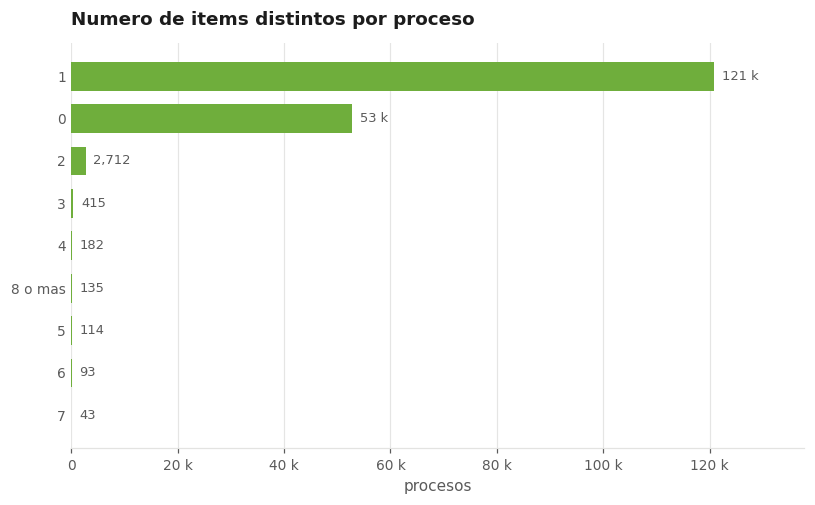

In [28]:
tam_canasta = spark.sql("""
    SELECT CASE WHEN size(items_cubso) >= 8 THEN '8 o mas'
                ELSE CAST(size(items_cubso) AS STRING) END AS items_por_proceso,
           COUNT(*) AS procesos
    FROM contrataciones GROUP BY 1 ORDER BY 1
""").toPandas()

viz.barras_h(tam_canasta, "items_por_proceso", "procesos",
    titulo="Numero de items distintos por proceso",
    porque="""Decide si la Parte V es viable sobre esta definicion de transaccion. Una canasta
              de un solo item no aporta co-ocurrencia; si dominaran, habria que redefinir la
              transaccion antes de aplicar FP-Growth.""",
    nombre="f15_tamano_canasta", etiqueta_x="procesos", color=viz.PALETA[2], alto_fila=0.42)

artefactos.exportar(tam_canasta, "p1_tamano_canasta", "Distribucion del numero de items por proceso.")
tam_canasta

La figura da una respuesta incómoda y hay que decirla con todas sus letras: **la canasta natural no sirve para minar reglas de asociación.** De 177.398 procesos, cerca de 121.000 tienen exactamente un ítem y unos 53.000 no tienen ninguno. Apenas unos 3.700 tienen dos o más. Un conjunto de un solo elemento no contiene co-ocurrencia, de modo que A-Priori y FP-Growth sobre esta definición devolverían únicamente conjuntos de tamaño uno, es decir, un ranking de frecuencias disfrazado de minería de patrones.

El motivo es que el catálogo CUBSO identifica el objeto del proceso, y la mayoría de los procesos de contratación peruanos tienen un objeto único. La analogía del supermercado no se sostiene a nivel de acto administrativo individual.

Esto no invalida la Parte V, obliga a redefinir la transacción, que es precisamente la decisión que el enunciado pide justificar. La pregunta correcta no es qué compró el Estado en un acto administrativo, sino qué compra junta una misma entidad dentro de un mismo período. Se evalúan abajo dos definiciones alternativas sobre el mismo dato.

,definicion,canastas,tam_medio,tam_mediano,tam_p90,tam_max,con_2_o_mas,pct_con_co_ocurrencia
0,proceso (natural),177398,0.74,1,1,130,3694,2.1
1,entidad y mes,37114,2.78,2,6,191,19911,53.6
2,entidad y trimestre,21098,4.49,2,10,337,14348,68.0


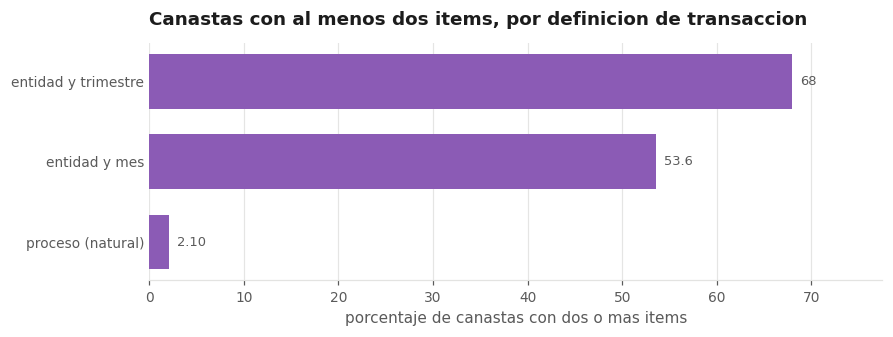

In [29]:
# Definicion alternativa A: la canasta es lo que una entidad compro en un mes.
# Definicion alternativa B: lo mismo, con ventana trimestral.
base_items = datos.filter("n_items > 0").withColumn("item", F.explode("items_cubso"))

alt_mes = (base_items.groupBy("comprador_id", "anio_mes")
           .agg(F.collect_set("item").alias("items")))
alt_trim = (base_items
            .withColumn("trimestre", F.concat_ws("T", F.col("anio"), F.ceil(F.col("mes") / 3)))
            .groupBy("comprador_id", "trimestre")
            .agg(F.collect_set("item").alias("items")))

def describir(df, etiqueta):
    d = df.withColumn("t", F.size("items"))
    r = d.select(
        F.count("*").alias("canastas"),
        F.round(F.mean("t"), 2).alias("tam_medio"),
        F.expr("percentile_approx(t, 0.5)").alias("tam_mediano"),
        F.expr("percentile_approx(t, 0.9)").alias("tam_p90"),
        F.max("t").alias("tam_max"),
        F.sum(F.when(F.col("t") > 1, 1).otherwise(0)).alias("con_2_o_mas"),
    ).collect()[0].asDict()
    r["definicion"] = etiqueta
    r["pct_con_co_ocurrencia"] = round(100 * r["con_2_o_mas"] / r["canastas"], 1)
    return r

natural = datos.select(F.size("items_cubso").alias("t")).select(
    F.count("*").alias("canastas"),
    F.round(F.mean("t"), 2).alias("tam_medio"),
    F.expr("percentile_approx(t, 0.5)").alias("tam_mediano"),
    F.expr("percentile_approx(t, 0.9)").alias("tam_p90"),
    F.max("t").alias("tam_max"),
    F.sum(F.when(F.col("t") > 1, 1).otherwise(0)).alias("con_2_o_mas"),
).collect()[0].asDict()
natural["definicion"] = "proceso (natural)"
natural["pct_con_co_ocurrencia"] = round(100 * natural["con_2_o_mas"] / natural["canastas"], 1)

comparacion = pd.DataFrame([natural, describir(alt_mes, "entidad y mes"),
                            describir(alt_trim, "entidad y trimestre")])[
    ["definicion", "canastas", "tam_medio", "tam_mediano", "tam_p90", "tam_max",
     "con_2_o_mas", "pct_con_co_ocurrencia"]]

viz.barras_h(comparacion, "definicion", "pct_con_co_ocurrencia",
    titulo="Canastas con al menos dos items, por definicion de transaccion",
    porque="""Es la figura que decide la Parte V. Solo las canastas con dos o mas items aportan
              co-ocurrencia, que es lo unico que A-Priori y FP-Growth pueden minar. Compara las
              tres definiciones candidatas sobre el mismo dato y deja la eleccion sustentada en
              una medida y no en una intuicion.""",
    nombre="f16_definicion_de_transaccion",
    etiqueta_x="porcentaje de canastas con dos o mas items",
    color=viz.PALETA[3], alto_fila=0.6)

artefactos.exportar(comparacion, "p1_definicion_transaccion",
                    "Comparacion de tres definiciones de transaccion para la Parte V.", parte="I y V")
comparacion

La comparación resuelve la decisión con una medida. Agrupar por entidad y mes produce unas 37.000 canastas con un tamaño medio de 2,8 ítems, y algo más de la mitad tiene dos o más. La ventana trimestral produce menos canastas pero más densas, con tamaño medio de 4,5. Ambas son minables; la natural no lo es.

Se adopta la ventana mensual como definición principal para la Parte V, por dos razones. La primera es que conserva más transacciones, y un mismo umbral de soporte relativo se vuelve más exigente, y por lo tanto más informativo, cuando hay más transacciones. La segunda es interpretativa: una regla del tipo la entidad que compra el ítem A compra también el ítem B dentro del mismo mes describe un patrón de abastecimiento reconocible, mientras que a escala trimestral la co-ocurrencia empieza a capturar simplemente que la entidad compra mucho. La ventana trimestral queda como variante de contraste, y comparar las reglas que produce cada una es en sí mismo un resultado a reportar.

Queda además una tercera variante para la Parte V, la canasta enriquecida, que agrega como ítems adicionales el método de contratación, el nivel de gobierno y el tramo de monto. Es la que permite que emerjan reglas del tipo cierto rubro junto con cierto método implica un solo postor, que responden directamente a la pregunta 2. Esa construcción corresponde a la Parte V y no se adelanta aquí.

In [30]:
# Diccionario de items, necesario para leer en palabras las reglas de la Parte V.
catalogo = perfil.catalogo_items(spark, cfg).orderBy(F.desc("apariciones")).toPandas()
artefactos.exportar(catalogo, "p1_catalogo_items",
                    "Diccionario de codigo CUBSO de 8 digitos a su descripcion mas frecuente.", parte="I y V")
print(f"Codigos CUBSO distintos: {len(catalogo):,}")
catalogo.head(12)

Codigos CUBSO distintos: 6,655


,item_cubso,etiqueta,apariciones
0,15101505,DIESEL B5 S-50,5093
1,72141003,SERVICIO DE MANTENIMIENTO RUTINARIO DE CAMINOS,4073
2,80101505,SERVICIO DE SEGUIMIENTO Y MONITOREO DE ACTIVIDADES DE CAMPO,3142
3,30111601,CEMENTO PORTLAND PUZOLANICO TIPO IP X 42.50 kg,2812
4,92101501,SERVICIO DE SEGURIDAD Y VIGILANCIA,2805
5,50131702,LECHE EVAPORADA ENTERA X 400 g APROX.,2264
6,80131502,SERVICIO DE ALQUILER DE INMUEBLE,1922
7,72141001,CONSTRUCCION DE CALLES CON PAVIMENTO,1367
8,72121403,SERVICIO DE MANTENIMIENTO DE INFRAESTRUCTURA DE CENTROS DE SALUD,1315
9,72141505,SERVICIO DE DESCOLMATACION DE RIOS DRENES Y QUEBRADAS,937


## 9. Procesamiento distribuido. MapReduce sobre RDD frente a DataFrames y Spark SQL

El enunciado pide implementar al menos dos agregaciones relevantes para las preguntas de interés en los dos estilos, compararlos en claridad y expresividad, y medir el tiempo de al menos una operación representativa.

Las dos agregaciones elegidas no son ejercicios: cada una alimenta una de las preguntas.

1. **Monto total y número de procesos por departamento.** Es el insumo territorial de la pregunta 1.
2. **Número medio de postores por método de contratación.** Es el insumo de la pregunta 2 y, de paso, el mismo agrupamiento que se usó para imputar la mediana de postores.

Una advertencia metodológica sobre la medición. Comparar los dos estilos es justo solo si ambos parten del mismo punto, así que los dos leen la misma tabla Parquet ya persistida. El camino RDD paga además el costo de serializar cada fila hacia el intérprete de Python, y ese costo no es un defecto del experimento: es exactamente la diferencia que se quiere medir.

In [31]:
tiempos = []

# Se fuerza la lectura desde disco en ambos casos para partir del mismo estado.
spark.catalog.clearCache()

# ---------------------------------------------------------------------------
# Agregacion A, estilo MapReduce sobre RDD
# map        : (departamento, (monto, 1))
# reduceByKey: suma parejas componente a componente, combinando en cada particion
#              antes de barajar, que es el equivalente al combiner de MapReduce
# ---------------------------------------------------------------------------
def agregacion_a_rdd():
    rdd = spark.read.parquet(str(ruta_parquet)).select("departamento", "monto_pen").rdd
    resultado = (rdd
        .map(lambda f: (f["departamento"], (f["monto_pen"], 1)))
        .reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1]))
        .mapValues(lambda v: (v[0] / 1e6, v[1]))
        .collect())
    return sorted(resultado, key=lambda t: -t[1][0])

with sesion.cronometro("A. por departamento, RDD (calentamiento)"):
    _ = agregacion_a_rdd()
with sesion.cronometro("A. por departamento, RDD", tiempos):
    a_rdd = agregacion_a_rdd()

pd.DataFrame([(d, round(m, 1), n) for d, (m, n) in a_rdd[:8]],
             columns=["departamento", "monto_millones", "procesos"])

A. por departamento, RDD (calentamiento): 1.40 s


A. por departamento, RDD: 0.44 s


,departamento,monto_millones,procesos
0,LIMA,118184.3,52896
1,LORETO,11432.9,4040
2,JUNIN,10878.3,6967
3,PIURA,8664.7,6284
4,CUSCO,8635.1,17229
5,LA LIBERTAD,8622.6,6451
6,PASCO,8452.2,2368
7,AREQUIPA,7814.9,7143


In [32]:
# ---------------------------------------------------------------------------
# Agregacion A, estilo declarativo con DataFrame
# ---------------------------------------------------------------------------
def agregacion_a_df():
    return (spark.read.parquet(str(ruta_parquet))
            .groupBy("departamento")
            .agg((F.sum("monto_pen") / 1e6).alias("monto_millones"),
                 F.count("*").alias("procesos"))
            .orderBy(F.desc("monto_millones"))
            .collect())

with sesion.cronometro("A. por departamento, DataFrame (calentamiento)"):
    _ = agregacion_a_df()
with sesion.cronometro("A. por departamento, DataFrame", tiempos):
    a_df = agregacion_a_df()

a_df_pd = pd.DataFrame([r.asDict() for r in a_df]).round(1)
artefactos.exportar(a_df_pd, "p1_monto_por_departamento",
                    "Monto total y numero de procesos por departamento.")
a_df_pd.head(8)

A. por departamento, DataFrame (calentamiento): 0.31 s


A. por departamento, DataFrame: 0.20 s


,departamento,monto_millones,procesos
0,LIMA,118184.3,52896
1,LORETO,11432.9,4040
2,JUNIN,10878.3,6967
3,PIURA,8664.7,6284
4,CUSCO,8635.1,17229
5,LA LIBERTAD,8622.6,6451
6,PASCO,8452.2,2368
7,AREQUIPA,7814.9,7143


In [33]:
# Verificacion de que los dos caminos entregan el mismo resultado.
comp = (pd.DataFrame([(d, m, n) for d, (m, n) in a_rdd], columns=["departamento", "monto_rdd", "proc_rdd"])
        .merge(a_df_pd.rename(columns={"monto_millones": "monto_df", "procesos": "proc_df"}),
               on="departamento"))
comp["dif_monto"] = (comp["monto_rdd"] - comp["monto_df"]).abs()
print(f"Departamentos comparados : {len(comp)}")
print(f"Diferencia maxima de monto: {comp['dif_monto'].max():.6f} millones de soles")
print(f"Conteos identicos        : {(comp['proc_rdd'] == comp['proc_df']).all()}")

Departamentos comparados : 25
Diferencia maxima de monto: 0.046537 millones de soles
Conteos identicos        : True


In [34]:
# ---------------------------------------------------------------------------
# Agregacion B, postores medios por metodo, en los dos estilos
# ---------------------------------------------------------------------------
def agregacion_b_rdd():
    rdd = (spark.read.parquet(str(ruta_parquet))
           .filter("NOT n_postores_imputado")
           .select("metodo_detalle", "n_postores").rdd)
    return (rdd
        .map(lambda f: (f["metodo_detalle"], (f["n_postores"] or 0.0, 1)))
        .reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1]))
        .mapValues(lambda v: v[0] / v[1])
        .collect())

def agregacion_b_sql():
    return spark.sql("""
        SELECT metodo_detalle, AVG(n_postores) AS postores_medio, COUNT(*) AS procesos
        FROM contrataciones WHERE NOT n_postores_imputado
        GROUP BY metodo_detalle ORDER BY postores_medio DESC
    """).collect()

with sesion.cronometro("B. postores por metodo, RDD", tiempos):
    b_rdd = agregacion_b_rdd()
with sesion.cronometro("B. postores por metodo, Spark SQL", tiempos):
    b_sql = agregacion_b_sql()

b_pd = pd.DataFrame([r.asDict() for r in b_sql]).round(2)
artefactos.exportar(b_pd, "p1_postores_por_metodo",
                    "Numero medio de postores por metodo de contratacion, excluyendo valores imputados.")
b_pd.head(10)

B. postores por metodo, RDD: 0.51 s
B. postores por metodo, Spark SQL: 0.16 s


,metodo_detalle,postores_medio,procesos
0,Adjudicación Simplificada - Ley N° 31579,29.00,1
1,Adjudicación Simplificada - Ley N° 31589,28.38,8
2,Adjudicación Simplificada-Decreto Legislativo N° 1577,27.23,69
3,Concurso Público,26.50,6254
4,Concurso Público de Servicios,25.08,970
5,Procedimiento Especial de Contratación,24.08,520
6,Adjudicación Simplificada - Ley N° 31728,23.37,668
7,Licitación Pública,21.83,7953
8,Adjudicación Simplificada - Decreto Urgencia 012-2023,21.50,6
9,Concurso Público Abreviado - Ley N°26859,21.00,5


In [35]:
medicion = pd.DataFrame(tiempos)
medicion["estilo"] = np.where(medicion["operacion"].str.contains("RDD"), "RDD", "DataFrame / SQL")
medicion["agregacion"] = np.where(medicion["operacion"].str.startswith("A."), "A. por departamento",
                                                                             "B. por metodo")
tabla_tiempos = medicion.pivot(index="agregacion", columns="estilo", values="segundos")
tabla_tiempos["veces_mas_lento_rdd"] = (tabla_tiempos["RDD"] / tabla_tiempos["DataFrame / SQL"]).round(1)

artefactos.exportar(tabla_tiempos.reset_index(), "p1_tiempos_rdd_vs_dataframe",
                    "Tiempo de pared de las dos agregaciones en estilo RDD y en estilo declarativo.")
tabla_tiempos.round(2)

estilo,DataFrame / SQL,RDD,veces_mas_lento_rdd
agregacion,,,
A. por departamento,0.20,0.44,2.2
B. por metodo,0.16,0.51,3.1


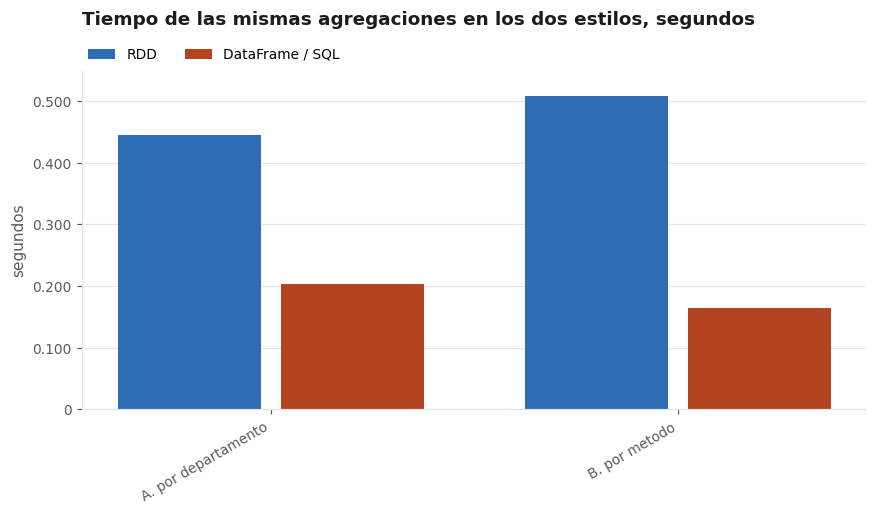

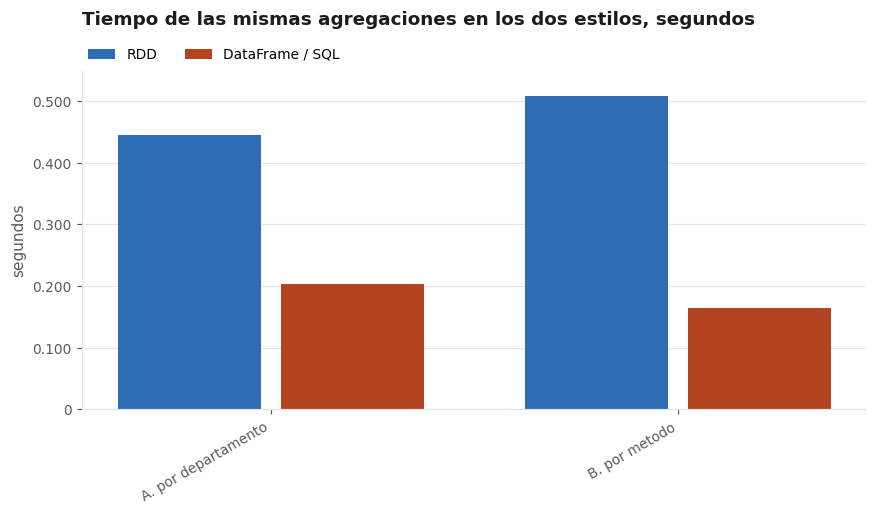

In [36]:
viz.barras_agrupadas(
    tabla_tiempos.reset_index(), "agregacion", ["RDD", "DataFrame / SQL"],
    titulo="Tiempo de las mismas agregaciones en los dos estilos, segundos",
    porque="""Cuantifica el costo del estilo imperativo. La diferencia no es una preferencia de
              gusto: el camino RDD serializa cada fila hacia el interprete de Python y pierde
              todas las optimizaciones del planificador, y eso se mide.""",
    nombre="f17_tiempos_rdd_vs_dataframe", etiqueta_y="segundos")

### 9.1 Comparación de los dos enfoques

| Aspecto | MapReduce sobre RDD | DataFrame y Spark SQL |
| --- | --- | --- |
| Qué se escribe | Cómo transformar cada fila y cómo combinar los resultados parciales. Es programación imperativa sobre una colección distribuida. | Qué resultado se quiere. El planificador decide cómo obtenerlo. |
| Líneas de código de la agregación A | Cuatro operaciones encadenadas con dos funciones anónimas que el lector debe interpretar mentalmente. | Una sola expresión que se lee casi como la pregunta de negocio. |
| Conocimiento del esquema | Ninguno. Spark ve tuplas opacas y no puede validar tipos ni nombres hasta la ejecución. | Completo. Un error de nombre de columna se detecta al planificar, no tras minutos de cómputo. |
| Optimización | La que el programador escriba a mano. Poner un filtro antes o después del map es responsabilidad suya. | Catalyst reordena filtros, poda columnas y elige la estrategia de unión. Tungsten opera sobre memoria fuera del montículo y evita crear objetos de Python. |
| Serialización | Cada fila cruza la frontera entre la máquina virtual de Java y el intérprete de Python. Es el costo dominante en PySpark. | El cómputo se queda dentro de la máquina virtual de Java. Python solo envía el plan. |
| Cuándo conviene igual | Lógica que no se expresa en SQL: recorridos con estado, estructuras de datos propias, algoritmos iterativos a medida. Buena parte de las Partes II y IV caen aquí. | Todo lo que sea seleccionar, filtrar, agrupar, unir y agregar, que es la totalidad de este EDA. |

La conclusión práctica para el resto del proyecto es directa. El EDA y las agregaciones van en DataFrames sin discusión. Los RDD se reservan para lo que realmente los necesita: la construcción de firmas MinHash y el agrupamiento por bandas de LSH en la Parte II, y la simulación del flujo con estructuras de resumen en la Parte IV, donde el estado que se mantiene entre elementos no tiene expresión declarativa.

Conviene además no sobreinterpretar la diferencia de tiempos medida. Sobre 177.000 filas ambos caminos terminan en segundos, y la elección entre ellos se decide por claridad, no por rendimiento. La brecha crece con el volumen, y es ahí donde la decisión empieza a costar dinero.

## 10. Particionado y su efecto sobre el plan de ejecución

Una partición es la unidad de paralelismo: Spark asigna una tarea por partición y las ejecuta en paralelo hasta agotar los núcleos disponibles. Tres decisiones de particionado se tomaron en este notebook y aquí se verifica el efecto de cada una leyendo el plan de ejecución.

In [37]:
print("Particiones al leer el Parquet particionado por anio:",
      spark.read.parquet(str(ruta_parquet)).rdd.getNumPartitions())
print("Directorios fisicos:", sorted(p.name for p in ruta_parquet.glob("anio=*")))
print("Valor de spark.sql.shuffle.partitions:", spark.conf.get("spark.sql.shuffle.partitions"))
print("Nucleos disponibles para tareas:", spark.sparkContext.defaultParallelism)

Particiones al leer el Parquet particionado por anio: 8
Directorios fisicos: ['anio=2023', 'anio=2024', 'anio=2025']
Valor de spark.sql.shuffle.partitions: 16
Nucleos disponibles para tareas: 8


### 10.1 Poda de particiones

La partición física por año permite que Spark descarte directorios enteros sin abrirlos cuando la consulta filtra por esa columna. Se comprueba comparando el plan de una consulta con filtro de año contra el de una con filtro sobre una columna no particionada.

In [38]:
plan_podado = (spark.read.parquet(str(ruta_parquet))
               .filter("anio = 2024")
               .groupBy("categoria").count())

print("=== Filtro sobre la columna de particion ===")
plan_podado.explain(mode="formatted")

=== Filtro sobre la columna de particion ===
== Physical Plan ==
AdaptiveSparkPlan (6)
+- HashAggregate (5)
   +- Exchange (4)
      +- HashAggregate (3)
         +- Project (2)
            +- Scan parquet  (1)


(1) Scan parquet 
Output [2]: [categoria#1051992, anio#1052018]
Batched: true
Location: InMemoryFileIndex [file:/home/germain/Documentos/Python_Projects/DataMining/PROYECTO/data/processed/tabla_analitica.parquet]
PartitionFilters: [isnotnull(anio#1052018), (anio#1052018 = 2024)]
ReadSchema: struct<categoria:string>

(2) Project
Output [1]: [categoria#1051992]
Input [2]: [categoria#1051992, anio#1052018]

(3) HashAggregate
Input [1]: [categoria#1051992]
Keys [1]: [categoria#1051992]
Functions [1]: [partial_count(1)]
Aggregate Attributes [1]: [count#1052057L]
Results [2]: [categoria#1051992, count#1052058L]

(4) Exchange
Input [2]: [categoria#1051992, count#1052058L]
Arguments: hashpartitioning(categoria#1051992, 16), ENSURE_REQUIREMENTS, [plan_id=9706]

(5) HashAggregate
Input 

In [39]:
plan_sin_podar = (spark.read.parquet(str(ruta_parquet))
                  .filter("categoria = 'works'")
                  .groupBy("anio").count())

print("=== Filtro sobre una columna NO particionada ===")
plan_sin_podar.explain(mode="formatted")

=== Filtro sobre una columna NO particionada ===
== Physical Plan ==
AdaptiveSparkPlan (7)
+- HashAggregate (6)
   +- Exchange (5)
      +- HashAggregate (4)
         +- Project (3)
            +- Filter (2)
               +- Scan parquet  (1)


(1) Scan parquet 
Output [2]: [categoria#1052067, anio#1052093]
Batched: true
Location: InMemoryFileIndex [file:/home/germain/Documentos/Python_Projects/DataMining/PROYECTO/data/processed/tabla_analitica.parquet]
PushedFilters: [IsNotNull(categoria), EqualTo(categoria,works)]
ReadSchema: struct<categoria:string>

(2) Filter
Input [2]: [categoria#1052067, anio#1052093]
Condition : (isnotnull(categoria#1052067) AND (categoria#1052067 = works))

(3) Project
Output [1]: [anio#1052093]
Input [2]: [categoria#1052067, anio#1052093]

(4) HashAggregate
Input [1]: [anio#1052093]
Keys [1]: [anio#1052093]
Functions [1]: [partial_count(1)]
Aggregate Attributes [1]: [count#1052132L]
Results [2]: [anio#1052093, count#1052133L]

(5) Exchange
Input [2]: [anio#1

La lectura de los dos planes deja ver la diferencia que importa.

En el primero, la línea PartitionFilters contiene la condición sobre el año. Spark resuelve ese filtro en el catálogo de archivos, antes de leer un solo byte de datos, y abre únicamente el directorio correspondiente. El número de archivos leídos baja a un tercio.

En el segundo, la condición aparece en PushedFilters y no en PartitionFilters. Spark abre los tres directorios, pero aprovecha las estadísticas que Parquet guarda por grupo de filas para saltar bloques enteros sin descomprimirlos. Es una optimización real y gratuita, pero de segundo orden comparada con no abrir el archivo.

La conclusión de diseño es que la columna de partición debe elegirse por cómo se consulta la tabla, no por cómo se ve. Aquí el año es la elección correcta porque toda la Parte IV recorre el dato en orden temporal. Particionar por departamento hubiera dado veinticinco directorios muy desiguales, con Lima concentrando una fracción enorme del total, y esa asimetría se paga en cada barajado posterior.

### 10.2 Barajado y número de particiones de salida

Toda agregación por clave obliga a un barajado: las filas con la misma clave tienen que terminar en la misma partición. El plan lo muestra como un intercambio con particionado por hash. El parámetro spark.sql.shuffle.partitions fija en cuántas particiones se reparte esa salida, y es el parámetro de Spark que más veces está mal puesto.

modo,shuffle_partitions,adaptativo activo,adaptativo desactivado
0,4,0.26,0.11
1,16,0.16,0.12
2,64,0.17,0.17
3,200,0.17,0.41


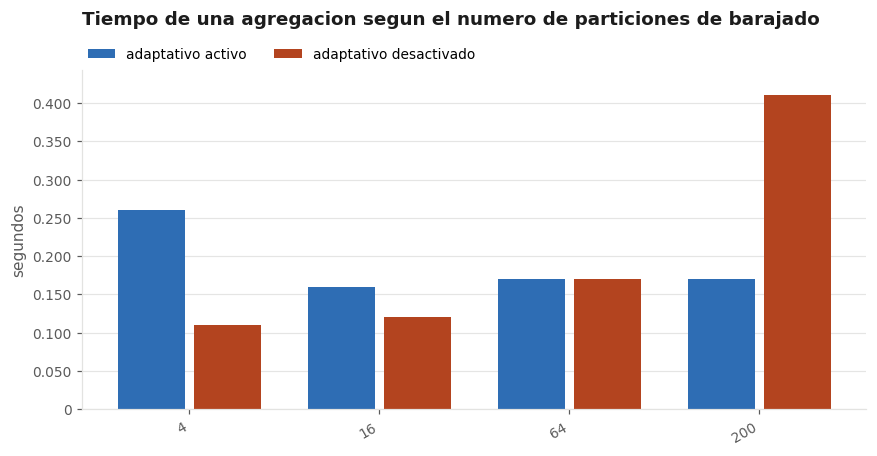

In [40]:
# El efecto del numero de particiones de barajado se mide dos veces: con la
# ejecucion adaptativa activa, que es la configuracion real del proyecto, y sin
# ella, que es lo que aisla el efecto del parametro.
prueba = []
for adaptativo in (True, False):
    for n_part in (4, 16, 64, 200):
        spark.conf.set("spark.sql.adaptive.enabled", str(adaptativo).lower())
        spark.conf.set("spark.sql.shuffle.partitions", str(n_part))
        spark.catalog.clearCache()
        t0 = time.perf_counter()
        (spark.read.parquet(str(ruta_parquet))
            .groupBy("departamento", "categoria", "metodo_detalle")
            .agg(F.sum("monto_pen").alias("m"), F.count("*").alias("n"))
            .collect())
        prueba.append({"shuffle_partitions": n_part,
                       "modo": "adaptativo activo" if adaptativo else "adaptativo desactivado",
                       "segundos": round(time.perf_counter() - t0, 2)})

spark.conf.set("spark.sql.adaptive.enabled", "true")
spark.conf.set("spark.sql.shuffle.partitions", str(cfg["particionado"]["n_particiones_shuffle"]))

prueba_pd = pd.DataFrame(prueba).pivot(index="shuffle_partitions", columns="modo",
                                       values="segundos").reset_index()
artefactos.exportar(prueba_pd, "p1_efecto_shuffle_partitions",
                    "Tiempo de una agregacion con distinto numero de particiones de barajado, "
                    "con y sin ejecucion adaptativa.")

viz.barras_agrupadas(
    prueba_pd.assign(shuffle_partitions=prueba_pd["shuffle_partitions"].astype(str)),
    "shuffle_partitions", ["adaptativo activo", "adaptativo desactivado"],
    titulo="Tiempo de una agregacion segun el numero de particiones de barajado",
    porque="""Aisla el efecto del parametro. Con ejecucion adaptativa Spark fusiona las
              particiones pequenas despues del barajado y el parametro casi deja de importar;
              sin ella, el costo de planificar y lanzar cientos de tareas diminutas se vuelve
              visible. Medir las dos configuraciones es lo que permite atribuir la diferencia al
              mecanismo correcto y no al azar.""",
    nombre="f18_efecto_shuffle_partitions", etiqueta_y="segundos")

prueba_pd

El resultado obliga a un matiz que no estaba en la hipótesis de partida. Con la ejecución adaptativa activa, que es la configuración real de este proyecto, el número de particiones de barajado casi no cambia el tiempo: Spark conoce el tamaño real de la salida del barajado y fusiona las particiones pequeñas antes de lanzar la etapa siguiente, de modo que doscientas particiones declaradas terminan siendo unas pocas efectivas. El parámetro queda amortiguado por el propio motor.

Con la ejecución adaptativa desactivada aparece el efecto que la teoría anticipa, y aparece por los dos extremos. Con cuatro particiones no se ocupan los ocho núcleos y cada tarea procesa demasiado. Con doscientas se planifican, lanzan y recogen doscientas tareas que procesan unos cientos de filas cada una, y ese costo fijo domina sobre el cálculo.

Hay que ser honesto sobre la magnitud: en valor absoluto la diferencia se mide en décimas de segundo, porque la tabla tiene 177.398 filas y cabe entera en memoria. La conclusión operativa no es que el parámetro sea irrelevante, sino que su efecto crece con el volumen y que la ejecución adaptativa es la que hace que una mala elección no se pague de inmediato. Sobre un volumen cien veces mayor, con barajados que no caben en memoria, el mismo error de configuración sí se paga, y esa es una de las preguntas que la Parte VI tiene que responder.

La regla de partida sigue siendo razonable: fijar el número de particiones de barajado en el orden de dos a cuatro veces el número de núcleos, que es lo que se hizo al ponerlo en dieciséis, y dejar que la ejecución adaptativa corrija el resto.

## 11. Etapa de interpretación

Las respuestas preliminares a las tres preguntas, con lo que este notebook alcanza a mostrar y señalando qué queda para las partes siguientes.

**Pregunta 1, concentración de proveedores.** La respuesta es cuantitativa y contundente: el coeficiente de Gini del monto adjudicado por proveedor es 0,857, y el uno por ciento de los proveedores concentra el 47 por ciento del dinero. El corte territorial obliga a un matiz que el agregado esconde, y que va en dirección contraria a la esperada: solo dos departamentos superan la concentración nacional, Pasco con 0,909 y Lima con 0,899, y todos los demás quedan por debajo. Es decir que el Gini nacional no describe un patrón que se repite en cada región, sino que está empujado hacia arriba por Lima, que sola concentra 72.148 millones de soles. Un mercado regional típico está menos concentrado que el país. Lo que este notebook no puede decidir es si esa concentración responde a especialización legítima o a proveedores que son en realidad la misma empresa bajo razones sociales distintas. Esa es exactamente la pregunta que contesta la Parte II con MinHash y LSH sobre los nombres y los objetos contractuales.

**Pregunta 2, competencia efectiva.** El número mediano de postores sí crece con el monto, de forma monótona y sin excepciones: 1 postor por debajo de cincuenta mil soles, 7 entre cincuenta y doscientos mil, y de ahí en adelante 11, 15, 18 y 19. Lo interesante no es esa tendencia sino dónde se rompe. En el tramo más bajo el 57 por ciento de los procesos tuvo un único postor, mientras que en todos los demás tramos esa proporción se estabiliza alrededor del 10 por ciento y ya no baja más, ni siquiera por encima de veinte millones de soles. Hay entonces dos fenómenos distintos: una franja de compras pequeñas que es competitiva solo en el papel, y un suelo de aproximadamente uno de cada diez procesos sin competencia que persiste en todo el rango de montos. El hallazgo se sostiene sobre los procesos con dato observado, excluyendo los imputados, precisamente para que la relación no la produzca la imputación. Queda pendiente identificar qué entidades concentran los casos de postor único de forma sistemática, que es una pregunta de patrones frecuentes y corresponde a la Parte V.

**Pregunta 3, estacionalidad.** Diciembre es el mes de mayor número de convocatorias tanto en 2023 como en 2024, los dos años con cobertura completa, y diciembre de 2024 es además el máximo de monto de toda la serie con 14.373 millones de soles, más del doble del mes anterior. El patrón se repite en los dos años, que es lo que permite leerlo como calendario presupuestal y no como ruido de un año particular. El tramo final de 2025 no contradice esto: su caída es un artefacto de cobertura, porque los procesos tardan en entrar al registro OCDS y los meses más recientes están subpublicados. Esa limitación queda anotada y debe respetarse en la Parte IV, donde la simulación del flujo no debe interpretar la cola de 2025 como una caída real de la contratación. Esta es además la variable que gobierna la Parte IV: la simulación del flujo respeta el orden de convocatoria, de modo que las estructuras de resumen ven la misma estacionalidad que el EDA acaba de describir.

**Qué heredan las partes siguientes.** La tabla analítica persistida deja listas tres representaciones que no hay que volver a construir:

1. El campo de texto normalizado del objeto contractual, del que salen los shingles de la Parte II y los vectores TF-IDF de la Parte III.
2. El conjunto de códigos CUBSO por proceso, que es a la vez la entrada de Jaccard en la Parte II y la canasta de la Parte V.
3. La fecha de convocatoria con resolución de minuto, que ordena el flujo de la Parte IV.

## 12. Artefactos exportados

La arquitectura del reporte web es calcular una vez y explorar muchas. Spark deja aquí agregados pequeños en CSV y JSON, y la página los lee sin volver a invocar Spark. Estas son las tablas y figuras que este notebook deja disponibles.

In [41]:
inventario = artefactos.manifiesto()
print(f"Artefactos de datos exportados: {len(inventario)}")
inventario

Artefactos de datos exportados: 26


,nombre,parte,filas,descripcion
0,p1_perfil_columnas,I,31,"Tipo, nulos y cardinalidad aproximada de cada columna de la tabla ..."
1,p1_duplicados,I,1,Verificacion de unicidad de la clave ocid.
2,p1_diagnostico_inconsistencias,I,1,Recuento de las inconsistencias detectadas antes de limpiar.
3,p1_paquete_vs_anio,I,3,Procesos por anio de paquete descargado frente a anio de convocato...
4,p1_verificacion_codificacion,I,15,"Caracteres corrompidos reparados y conservados, con su conteo tras..."
5,p1_bitacora_limpieza,I,13,"Bitacora de limpieza: accion, filas afectadas y justificacion de c..."
6,p1_outliers_monto,I,2,Procesos marcados como extremos por monto frente al resto.
7,p1_resumen_numerico,I,4,Estadisticos robustos de las variables numericas tras la limpieza.
8,p1_serie_mensual,I,36,"Procesos, monto total y monto mediano por mes."
9,p1_estacionalidad,I,12,Procesos por mes y anio para el analisis de estacionalidad.


In [42]:
figuras = viz.manifiesto()
print(f"Figuras generadas: {len(figuras)}")
figuras[["figura", "titulo", "porque_se_genera"]]

Figuras generadas: 18


,figura,titulo,porque_se_genera
0,f01_paquete_vs_anio_convocatoria,El paquete anual no contiene solo procesos de ese anio,Justifica la politica de ventana temporal. La diagonal deberia con...
1,f02_embudo_limpieza,Filas que sobreviven despues de cada politica de limpieza,Hace visible el costo en datos de cada decision del preprocesamien...
2,f03_procesos_por_mes,"Procesos convocados por mes, 2023 a 2025",Primer control de la ventana temporal y base de la pregunta sobre ...
3,f04_monto_por_mes,"Monto convocado por mes, en millones de soles",Se separa del conteo de procesos porque son magnitudes de escalas ...
4,f05_estacionalidad_mes_anio,Procesos por mes y anio,Aisla el patron de calendario del ruido de cada anio. Si hubiera a...
5,f06_distribucion_monto,"Distribucion del valor referencial, escala logaritmica",El monto abarca seis ordenes de magnitud. En escala lineal la figu...
6,f07_procesos_por_metodo,Procesos por metodo de contratacion,El metodo determina las reglas de competencia de cada proceso y es...
7,f08_monto_por_metodo,"Monto convocado por metodo de contratacion, miles de millones de s...",Se contrasta con la figura anterior a proposito: el metodo que mas...
8,f09_nivel_gobierno,Volumen y monto por nivel de gobierno,"El nivel de gobierno es una variable derivada, no venia en el dato..."
9,f10_top_compradores,"Quince entidades con mayor monto convocado, millones de soles",Responde la mitad compradora de la pregunta de concentracion. Se o...


In [43]:
figuras.to_csv(cfg.ruta("artefactos") / "p1_manifiesto_figuras.csv", index=False)
print("Tabla analitica:", ruta_parquet)
print("Artefactos      :", cfg.ruta("artefactos"))
print("Figuras         :", cfg.ruta("figuras"))
spark.stop()
print("\nParte I completa.")

Tabla analitica: /home/germain/Documentos/Python_Projects/DataMining/PROYECTO/data/processed/tabla_analitica.parquet
Artefactos      : /home/germain/Documentos/Python_Projects/DataMining/PROYECTO/artifacts
Figuras         : /home/germain/Documentos/Python_Projects/DataMining/PROYECTO/figs



Parte I completa.
